# Deep Learning Lab - Image Classification
## MLP → CNN → Transfer Learning (CIFAR-10)

---

### Dataset: CIFAR-10

CIFAR-10 has 60,000 RGB images at 32x32 pixels across 10 balanced classes.
We sample 20 percent using stratified sampling so every class stays equally represented.
The dataset is built into torchvision so no external download is needed.

---

### Domain Investigation

We use ResNet18 pretrained on ImageNet as the backbone for transfer learning.

ImageNet: 1.2 million images, 1000 classes, 224x224 resolution, natural everyday objects.
CIFAR-10: 60,000 images, 10 classes, 32x32 resolution, natural everyday objects.

The domain gap is small. Both datasets are natural real-world images and all 10 CIFAR-10
classes exist somewhere within ImageNet's 1000 categories. Low-level features like edges,
textures, and color gradients are identical across both datasets.
The only mismatch is resolution, which we handle by resizing to 224x224 before feeding
images to the pretrained model.

This small domain gap means transfer learning should work well here.
Frozen early layers are already useful without any modification.

---

## Cell 0 - Install Packages

## Imports and Device

In [2]:
import json, time, copy, random, warnings, sys
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {DEVICE}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")

Device      : cuda
PyTorch     : 2.7.1+cu118
Torchvision : 0.22.1+cu118
GPU         : Quadro M1000M


---
## Data Loading

### Lazy Loading

PyTorch DataLoader reads images from disk one batch at a time during training.
Nothing is loaded into memory upfront. This is the standard way to handle
datasets of any size without running out of RAM.

We define two transform pipelines: one for MLP/CNN using the original 32x32 size
with CIFAR-10 normalization stats, and one for the pretrained ResNet that resizes
to 224x224 and uses ImageNet normalization stats.

In [3]:
SAMPLE_FRACTION  = 0.20
BATCH_SIZE_BASIC = 64
BATCH_SIZE_PT    = 32
NUM_CLASSES      = 10
NUM_WORKERS      = 2
EPOCHS_SIMPLE    = 15
EPOCHS_TL        = 10

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

transform_train_basic = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std =[0.2470, 0.2435, 0.2616])
])
transform_val_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std =[0.2470, 0.2435, 0.2616])
])

# ResNet requires 224x224 and ImageNet normalization stats
transform_train_pt = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])
transform_val_pt = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

full_train_basic = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True,  transform=transform_train_basic)
full_val_basic   = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=transform_val_basic)
full_train_pt    = torchvision.datasets.CIFAR10(root="./data", train=True,  download=False, transform=transform_train_pt)
full_val_pt      = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=transform_val_pt)

print(f"Full train : {len(full_train_basic):,}  |  Full val : {len(full_val_basic):,}")

Full train : 50,000  |  Full val : 10,000


In [4]:
def stratified_sample(dataset, fraction, seed=42):
    rng     = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    indices = []
    for cls in range(NUM_CLASSES):
        cls_idx  = np.where(targets == cls)[0]
        n_sample = max(1, int(len(cls_idx) * fraction))
        indices.extend(rng.choice(cls_idx, n_sample, replace=False).tolist())
    rng.shuffle(indices)
    return indices

train_idx = stratified_sample(full_train_basic, SAMPLE_FRACTION)
val_idx   = stratified_sample(full_val_basic,   SAMPLE_FRACTION)

counts = np.bincount(np.array(full_train_basic.targets)[train_idx])
print("Samples per class:")
for cls, cnt in zip(CLASSES, counts):
    print(f"  {cls:<14}: {cnt:,}")
print(f"\nTrain : {len(train_idx):,}  |  Val : {len(val_idx):,}")

train_subset_basic = Subset(full_train_basic, train_idx)
val_subset_basic   = Subset(full_val_basic,   val_idx)
train_subset_pt    = Subset(full_train_pt,    train_idx)
val_subset_pt      = Subset(full_val_pt,      val_idx)

pin = (DEVICE.type == "cuda")
train_loader_basic = DataLoader(train_subset_basic, batch_size=BATCH_SIZE_BASIC, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader_basic   = DataLoader(val_subset_basic,   batch_size=BATCH_SIZE_BASIC, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
train_loader_pt    = DataLoader(train_subset_pt,    batch_size=BATCH_SIZE_PT,    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader_pt      = DataLoader(val_subset_pt,      batch_size=BATCH_SIZE_PT,    shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f"\nBasic     -> train: {len(train_loader_basic)} batches | val: {len(val_loader_basic)} batches")
print(f"Pretrained -> train: {len(train_loader_pt)} batches | val: {len(val_loader_pt)} batches")

Samples per class:
  airplane      : 1,000
  automobile    : 1,000
  bird          : 1,000
  cat           : 1,000
  deer          : 1,000
  dog           : 1,000
  frog          : 1,000
  horse         : 1,000
  ship          : 1,000
  truck         : 1,000

Train : 10,000  |  Val : 2,000

Basic     -> train: 157 batches | val: 32 batches
Pretrained -> train: 313 batches | val: 63 batches


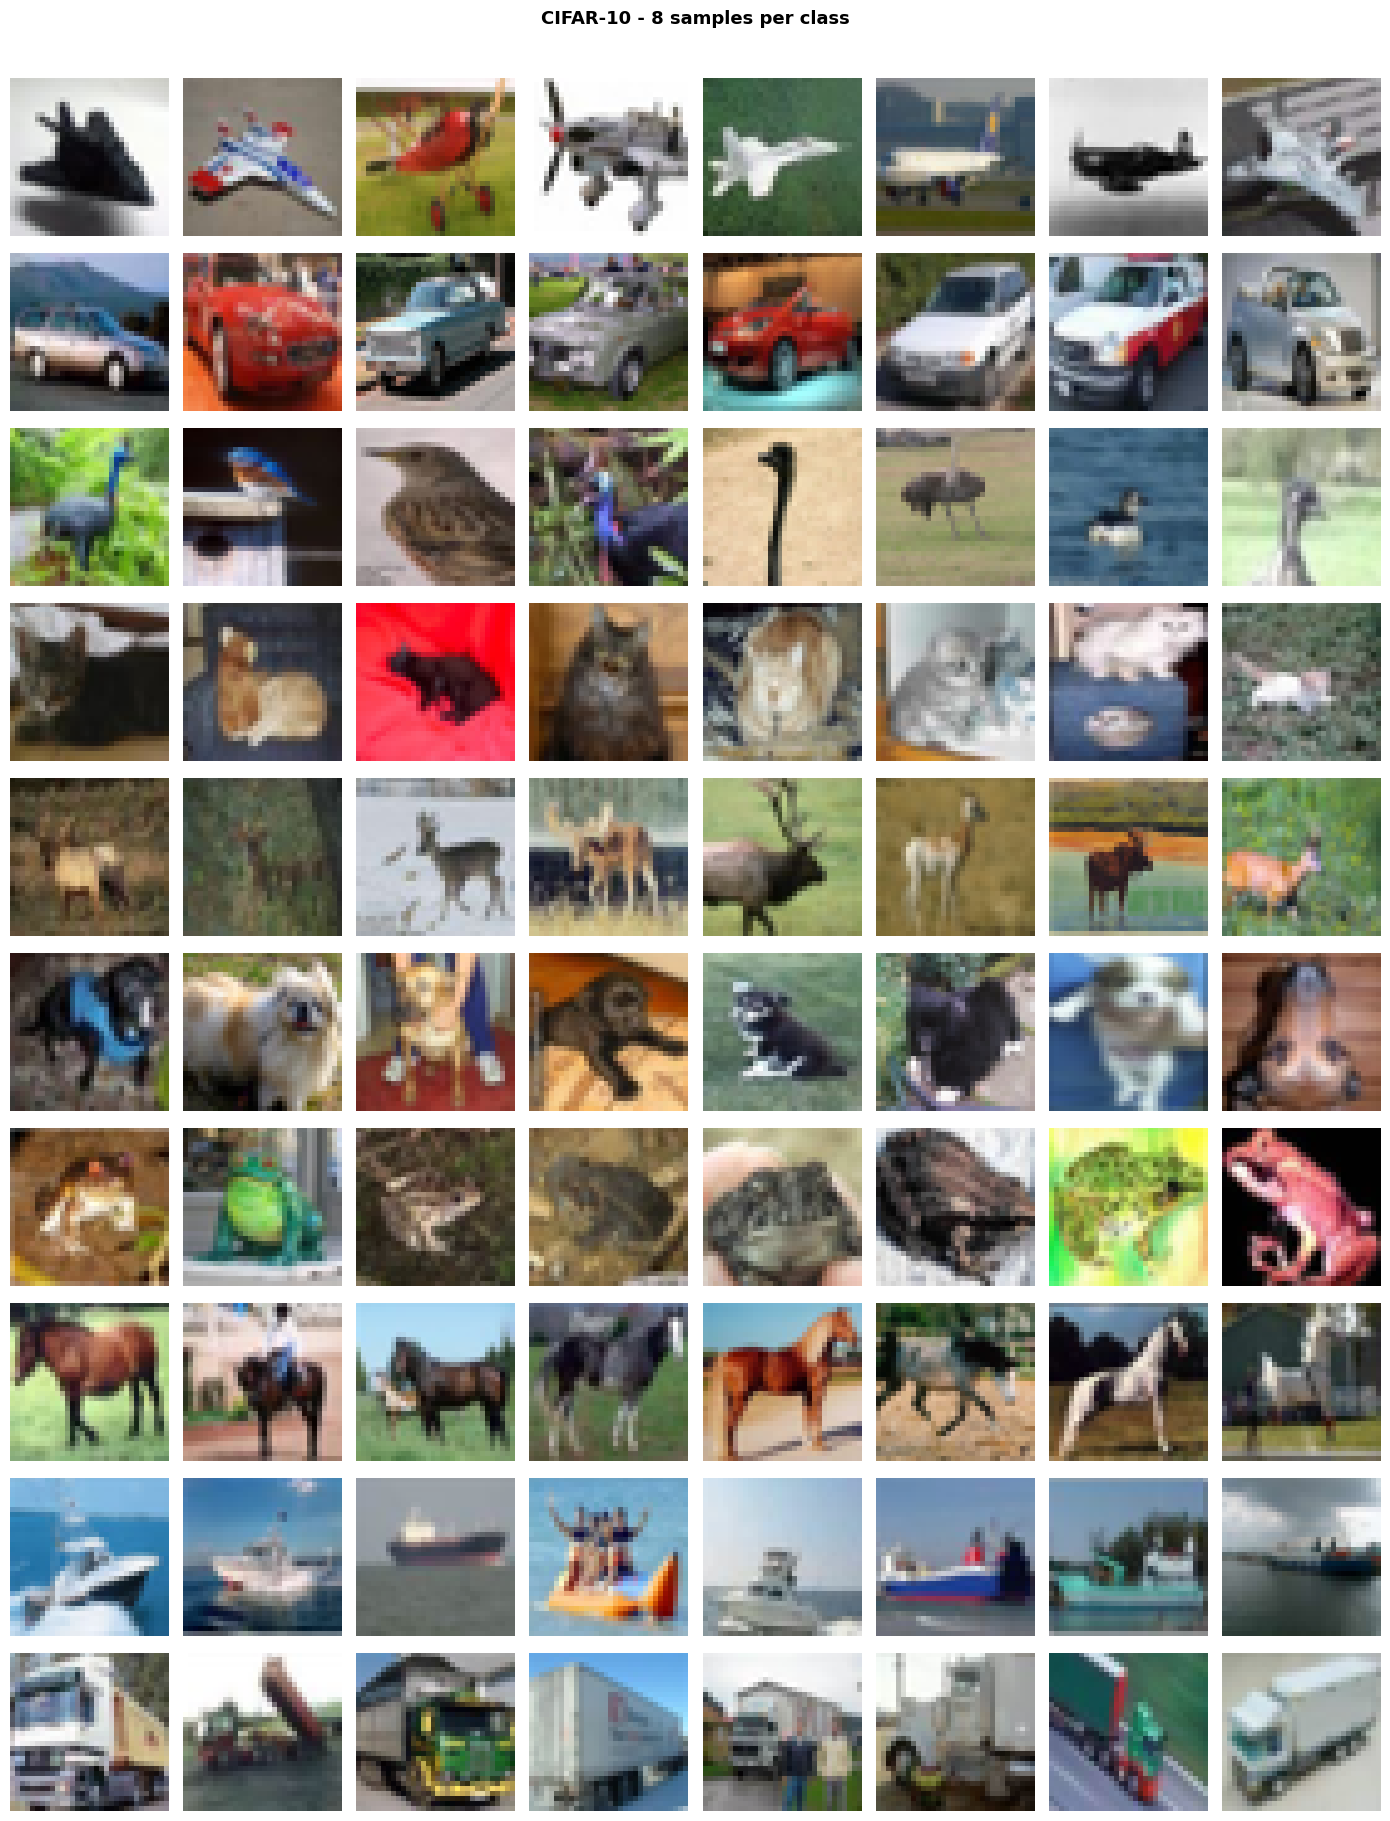

In [ ]:
# Sample images for visualization
raw = torchvision.datasets.CIFAR10(root="./data", train=True, download=False,
                                    transform=transforms.ToTensor())
fig, axes = plt.subplots(10, 8, figsize=(14, 18))
counter = {c: 0 for c in range(10)}
for img, label in raw:
    if counter[label] < 8:
        ax = axes[label][counter[label]]
        ax.imshow(img.permute(1,2,0).numpy())
        ax.axis("off")
        if counter[label] == 0:
            ax.set_ylabel(CLASSES[label], rotation=0, labelpad=55,
                          fontsize=10, fontweight="bold", va="center")
        counter[label] += 1
    if all(v == 8 for v in counter.values()):
        break
plt.suptitle("CIFAR-10 - 8 samples per class", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Training Utilities

In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = out.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, val_loader,
                 optimizer, criterion, scheduler=None,
                 epochs=10, model_name="model"):
    model.to(DEVICE)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc       = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)
        if scheduler:
            scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = copy.deepcopy(model.state_dict())
            marker = " <- best"
        else:
            marker = ""
        print(f"  Epoch {epoch:3d}/{epochs}  |  Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:6.2f}%"
              f"  |  Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:6.2f}%{marker}")

    model.load_state_dict(best_state)
    print(f"\n  Time: {time.time()-t0:.1f}s  |  Best Val Acc: {best_val_acc*100:.2f}%")
    history["best_val_acc"] = best_val_acc
    history["model_name"]   = model_name
    return history


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history["train_loss"]) + 1)
    ax1.plot(ep, history["train_loss"], "b-o", label="Train", ms=5, lw=2)
    ax1.plot(ep, history["val_loss"],   "r-o", label="Val",   ms=5, lw=2)
    ax1.set_title("Loss");   ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, [a*100 for a in history["train_acc"]], "b-o", label="Train", ms=5, lw=2)
    ax2.plot(ep, [a*100 for a in history["val_acc"]],   "r-o", label="Val",   ms=5, lw=2)
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("%"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


def plot_confusion(preds, labels, title=""):
    cm = confusion_matrix(labels, preds, normalize="true")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix - {title}", fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()


def print_metrics(preds, labels, model_name=""):
    acc = accuracy_score(labels, preds)
    rec = recall_score(labels, preds, average="macro")
    f1  = f1_score(labels,     preds, average="macro")
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy     : {acc*100:.2f}%")
    print(f"  Macro Recall : {rec*100:.2f}%")
    print(f"  Macro F1     : {f1*100:.2f}%")
    print(f"\n{classification_report(labels, preds, target_names=CLASSES)}")
    return {"accuracy": acc, "macro_recall": rec, "macro_f1": f1}


def get_first_conv_filters(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            return m.weight.detach().cpu().clone()

def plot_filters(filters, title, n=32, ncols=8):
    n     = min(n, filters.shape[0])
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.7, nrows*1.7))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f.permute(1,2,0).numpy(), interpolation="nearest")
            ax.set_title(f"F{i}", fontsize=5)
        ax.axis("off")
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

print("Utilities ready.")

Utilities ready.


---
## Feature Map Utility

This function registers forward hooks on a model's named layers,
runs one sample image through, then plots the resulting feature maps.
We call it after each model finishes training to see what the network
has learned to detect at each depth.

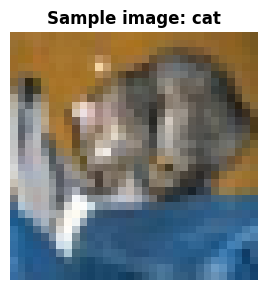

We will visualize feature maps for this 'cat' image across all models.


In [7]:
def show_feature_maps(model, sample_tensor, layer_names, title_prefix="", ncols=8, n_maps=16):
    """
    Register hooks on the given layer names, run a forward pass,
    then display n_maps feature maps per layer in a grid.

    layer_names : list of (display_name, module) tuples
    """
    model.eval()
    activations = {}

    def make_hook(name):
        def hook(module, inp, out):
            activations[name] = out.detach().cpu()
        return hook

    handles = []
    for name, module in layer_names:
        handles.append(module.register_forward_hook(make_hook(name)))

    with torch.no_grad():
        _ = model(sample_tensor.to(DEVICE))

    for h in handles:
        h.remove()

    n_layers = len(layer_names)
    fig, axes_all = plt.subplots(n_layers, ncols, figsize=(ncols * 1.8, n_layers * 2.2))
    if n_layers == 1:
        axes_all = [axes_all]

    for row, (name, _) in enumerate(layer_names):
        fmaps   = activations[name][0]              # (C, H, W)
        n_show  = min(n_maps, fmaps.shape[0])
        spatial = fmaps.shape[-1]
        row_axes = axes_all[row]

        for col in range(ncols):
            ax = row_axes[col]
            if col < n_show:
                fm = fmaps[col]
                fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
                ax.imshow(fm.numpy(), cmap="viridis", interpolation="nearest")
                ax.set_title(f"ch{col}", fontsize=6)
            ax.axis("off")

        row_axes[0].set_ylabel(
            f"{name}\n{fmaps.shape[0]}ch {spatial}x{spatial}",
            rotation=0, labelpad=90, fontsize=8, fontweight="bold", va="center"
        )

    plt.suptitle(f"{title_prefix} - Feature Maps (16 channels per layer)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Pick one fixed validation image to use for all feature map visualizations.
# Using the same image across all models makes comparisons meaningful.
SAMPLE_IMG, SAMPLE_LABEL = full_val_basic[0]
SAMPLE_TENSOR_BASIC = SAMPLE_IMG.unsqueeze(0)   # (1, 3, 32, 32)

# Also prepare a 224x224 version for pretrained models
SAMPLE_IMG_PT, _ = full_val_pt[0]
SAMPLE_TENSOR_PT = SAMPLE_IMG_PT.unsqueeze(0)   # (1, 3, 224, 224)

# Show the sample image
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
raw_img = torchvision.datasets.CIFAR10(root="./data", train=False, download=False,
                                        transform=transforms.ToTensor())[0][0]
ax.imshow(raw_img.permute(1,2,0).numpy())
ax.set_title(f"Sample image: {CLASSES[SAMPLE_LABEL]}", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()
print(f"We will visualize feature maps for this '{CLASSES[SAMPLE_LABEL]}' image across all models.")

---
## Part 1 - MLP

The MLP flattens each image from (3, 32, 32) into a vector of 3072 numbers.
All spatial relationships between pixels are permanently lost at this step.
The network treats each pixel as an independent feature with no connection to its neighbors.

This is our baseline. It should reach around 45-55% accuracy.
Anything a smarter architecture achieves above this number
is directly due to exploiting spatial structure.

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dims=[1024, 512, 256],
                 num_classes=10, dropout=0.4):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))   # flatten here

mlp_tmp = MLP()
print(f"MLP parameters: {sum(p.numel() for p in mlp_tmp.parameters()):,}")
with torch.no_grad():
    out = mlp_tmp(torch.randn(4, 3, 32, 32))
print(f"Output shape  : {out.shape}")

MLP parameters: 3,809,034
Output shape  : torch.Size([4, 10])


In [9]:
mlp_model = MLP().to(DEVICE)
mlp_crit  = nn.CrossEntropyLoss()
mlp_optim = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
mlp_sched = optim.lr_scheduler.CosineAnnealingLR(mlp_optim, T_max=EPOCHS_SIMPLE)

print("Training MLP...\n")
mlp_history = run_training(mlp_model, train_loader_basic, val_loader_basic,
                            mlp_optim, mlp_crit, mlp_sched,
                            epochs=EPOCHS_SIMPLE, model_name="MLP")

Training MLP...

  Epoch   1/15  |  Train Loss: 2.0630  Acc:  24.31%  |  Val Loss: 1.8448  Acc:  33.40% <- best
  Epoch   2/15  |  Train Loss: 1.9177  Acc:  29.94%  |  Val Loss: 1.7662  Acc:  36.30% <- best
  Epoch   3/15  |  Train Loss: 1.8507  Acc:  31.92%  |  Val Loss: 1.6944  Acc:  38.60% <- best
  Epoch   4/15  |  Train Loss: 1.8071  Acc:  34.21%  |  Val Loss: 1.6521  Acc:  40.35% <- best
  Epoch   5/15  |  Train Loss: 1.7815  Acc:  34.61%  |  Val Loss: 1.6513  Acc:  40.65% <- best
  Epoch   6/15  |  Train Loss: 1.7583  Acc:  35.93%  |  Val Loss: 1.5928  Acc:  42.55% <- best
  Epoch   7/15  |  Train Loss: 1.7270  Acc:  37.15%  |  Val Loss: 1.5670  Acc:  44.20% <- best
  Epoch   8/15  |  Train Loss: 1.7092  Acc:  37.71%  |  Val Loss: 1.5549  Acc:  43.95%
  Epoch   9/15  |  Train Loss: 1.6958  Acc:  38.01%  |  Val Loss: 1.5269  Acc:  44.55% <- best
  Epoch  10/15  |  Train Loss: 1.6668  Acc:  39.57%  |  Val Loss: 1.5073  Acc:  46.45% <- best
  Epoch  11/15  |  Train Loss: 1.6470  Ac

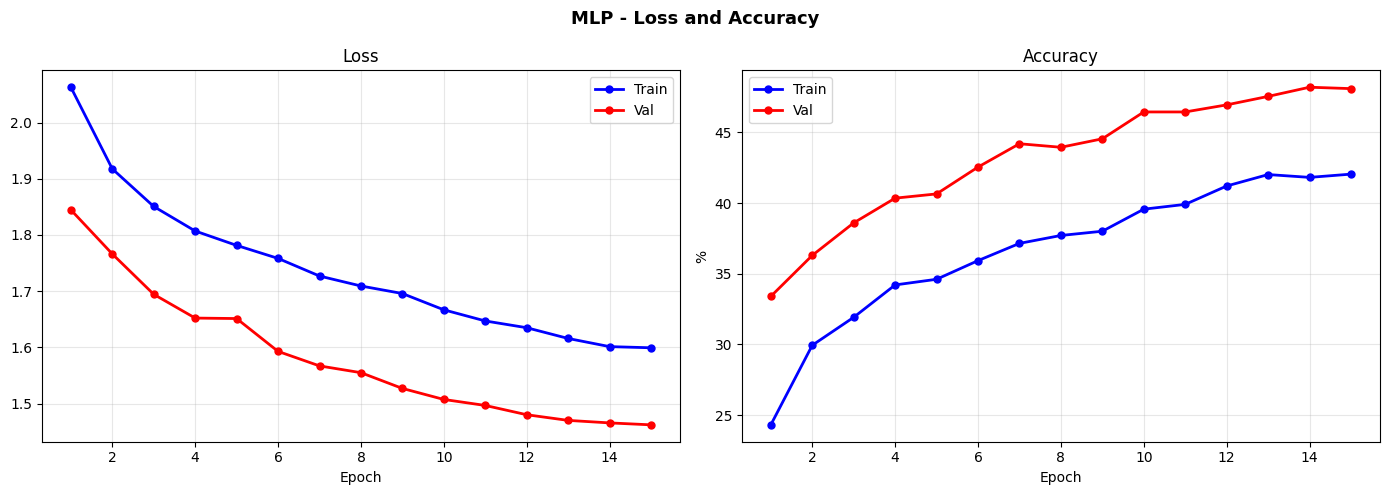


  MLP
  Accuracy     : 48.20%
  Macro Recall : 48.20%
  Macro F1     : 47.33%

              precision    recall  f1-score   support

    airplane       0.52      0.60      0.56       200
  automobile       0.58      0.56      0.57       200
        bird       0.40      0.34      0.37       200
         cat       0.37      0.28      0.32       200
        deer       0.43      0.28      0.34       200
         dog       0.45      0.34      0.39       200
        frog       0.44      0.59      0.51       200
       horse       0.48      0.58      0.52       200
        ship       0.59      0.60      0.60       200
       truck       0.50      0.63      0.56       200

    accuracy                           0.48      2000
   macro avg       0.48      0.48      0.47      2000
weighted avg       0.48      0.48      0.47      2000



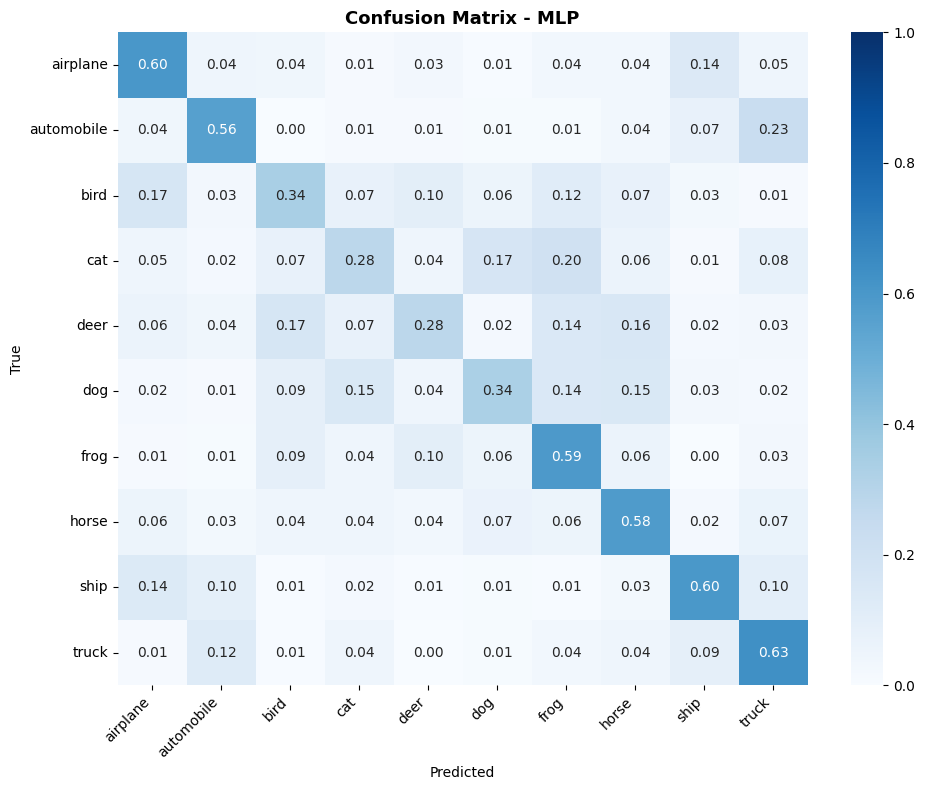

In [10]:
plot_history(mlp_history, "MLP - Loss and Accuracy")
_, _, mlp_preds, mlp_labels = evaluate(mlp_model, val_loader_basic, mlp_crit)
mlp_metrics = print_metrics(mlp_preds, mlp_labels, "MLP")
plot_confusion(mlp_preds, mlp_labels, "MLP")

### MLP - Feature Maps

An MLP has no intermediate spatial representations. There are no 2D feature maps to visualize.
Each hidden layer is just a vector of activations with no spatial meaning.

To still give a sense of what the MLP is doing internally, we visualize the activation
magnitudes of the three hidden layers for the sample image as bar charts.
This shows which neurons are most active and how information is compressed
as it moves toward the output.

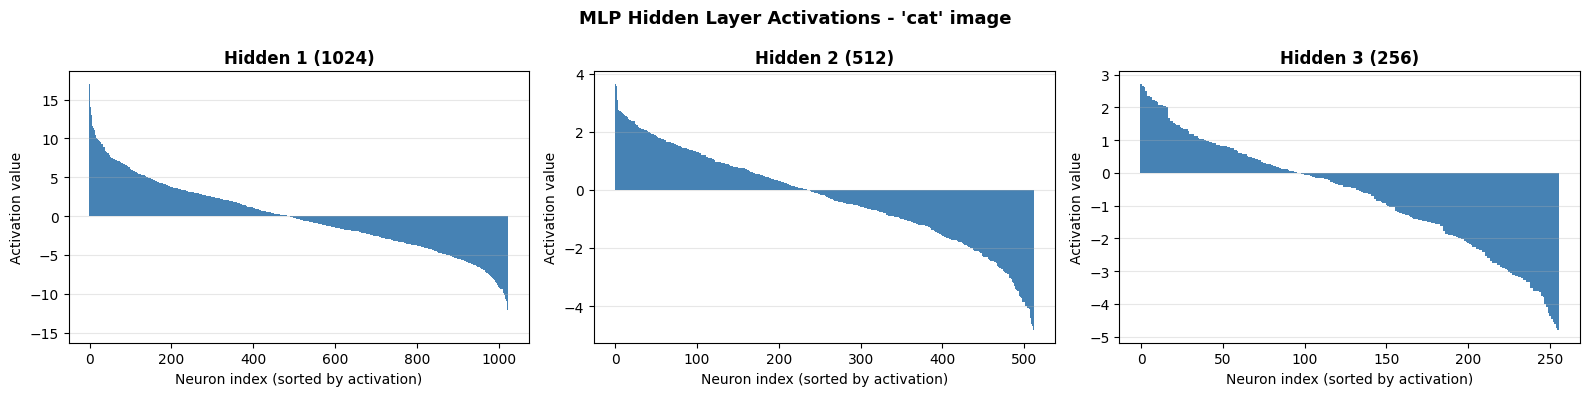

The activation bars show which neurons fire strongly for this image.
Unlike CNN feature maps, there is no spatial layout here.
We cannot tell what part of the image triggered a given neuron.


In [11]:
# MLP internal activations for the sample image
mlp_model.eval()
mlp_activations = {}

hooks = []
layer_labels = ["Hidden 1 (1024)", "Hidden 2 (512)", "Hidden 3 (256)"]
# layers 0, 4, 8 are the Linear layers in the Sequential
for idx, lbl in zip([0, 4, 8], layer_labels):
    def make_h(name):
        def h(m, i, o): mlp_activations[name] = o.detach().cpu()
        return h
    hooks.append(mlp_model.net[idx].register_forward_hook(make_h(lbl)))

with torch.no_grad():
    _ = mlp_model(SAMPLE_TENSOR_BASIC.to(DEVICE))
for h in hooks: h.remove()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, lbl in zip(axes, layer_labels):
    acts = mlp_activations[lbl][0].numpy()
    ax.bar(range(len(acts)), np.sort(acts)[::-1], color="steelblue", width=1.0)
    ax.set_title(lbl, fontweight="bold")
    ax.set_xlabel("Neuron index (sorted by activation)")
    ax.set_ylabel("Activation value")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"MLP Hidden Layer Activations - '{CLASSES[SAMPLE_LABEL]}' image",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("The activation bars show which neurons fire strongly for this image.")
print("Unlike CNN feature maps, there is no spatial layout here.")
print("We cannot tell what part of the image triggered a given neuron.")

### MLP Results

The accuracy is around 45-55%. The loss curves show training accuracy
pulling clearly ahead of validation, which is the overfitting signature.
The model memorizes training-set pixel patterns that do not transfer to new images.
Cat, dog, and bird are the most confused classes because
without spatial understanding their pixel distributions overlap heavily.

---
## Part 2 - CNN

A convolutional layer applies a small filter across the full image rather than
connecting every input pixel to every output neuron. The same filter weights are
reused at every position, which forces the network to learn patterns that generalize
across the image rather than memorizing position-specific correlations.

Stacking blocks creates a hierarchy: early layers detect edges and colors,
middle layers detect shapes, deeper layers detect object-level features.

Architecture rules applied here:
- 3x3 filters throughout, two per block before pooling
- Channels double after each max-pool (3 -> 64 -> 128 -> 256)
- BatchNorm after every conv layer
- Global Average Pooling instead of Flatten + large FC
- Kaiming weight initialization for ReLU networks
- Label smoothing in the loss function

In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if pool: layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x): return self.block(x)


class CNN(nn.Module):
    # Input (B, 3, 32, 32)
    # Block1 -> (B, 64,  16, 16)
    # Block2 -> (B, 128,  8,  8)
    # Block3 -> (B, 256,  4,  4)
    # GAP    -> (B, 256)
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        self.block1 = ConvBlock(3,   64)
        self.block2 = ConvBlock(64,  128)
        self.block3 = ConvBlock(128, 256)
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, 128),
            nn.ReLU(inplace=True), nn.Dropout(dropout/2),
            nn.Linear(128, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_tmp = CNN()
print(f"CNN parameters: {sum(p.numel() for p in cnn_tmp.parameters()):,}")
with torch.no_grad():
    d = torch.randn(2, 3, 32, 32)
    print(f"Output shape  : {cnn_tmp(d).shape}")

CNN parameters: 1,180,490
Output shape  : torch.Size([2, 10])


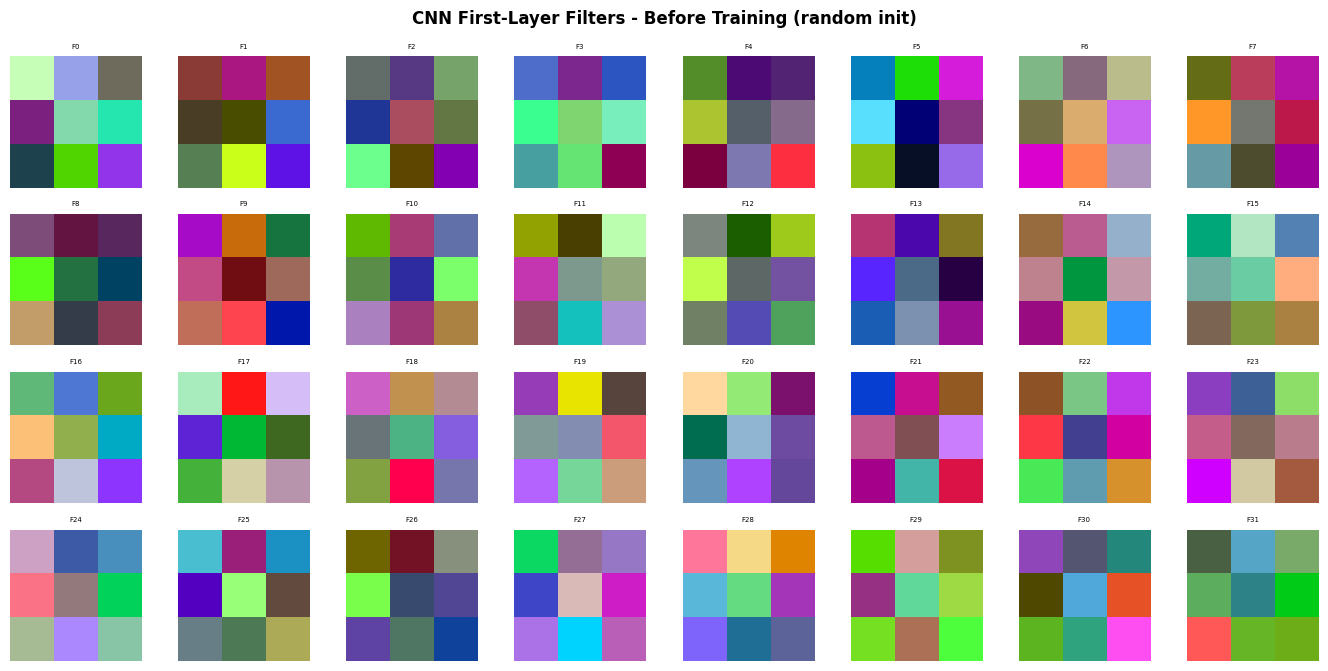

In [13]:
# Capture filters before any training for Part 4 comparison
cnn_model          = CNN().to(DEVICE)
filters_cnn_before = get_first_conv_filters(cnn_model)
plot_filters(filters_cnn_before, "CNN First-Layer Filters - Before Training (random init)", n=32, ncols=8)

In [14]:
cnn_crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
cnn_optim = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_sched = optim.lr_scheduler.CosineAnnealingLR(cnn_optim, T_max=EPOCHS_SIMPLE)

print("Training CNN...\n")
cnn_history = run_training(cnn_model, train_loader_basic, val_loader_basic,
                            cnn_optim, cnn_crit, cnn_sched,
                            epochs=EPOCHS_SIMPLE, model_name="CNN")

Training CNN...

  Epoch   1/15  |  Train Loss: 2.1147  Acc:  25.44%  |  Val Loss: 1.8578  Acc:  36.45% <- best
  Epoch   2/15  |  Train Loss: 1.8260  Acc:  37.25%  |  Val Loss: 1.9322  Acc:  30.95%
  Epoch   3/15  |  Train Loss: 1.6751  Acc:  45.09%  |  Val Loss: 1.5638  Acc:  50.80% <- best
  Epoch   4/15  |  Train Loss: 1.5642  Acc:  50.89%  |  Val Loss: 1.7426  Acc:  47.60%
  Epoch   5/15  |  Train Loss: 1.4945  Acc:  55.25%  |  Val Loss: 1.6293  Acc:  49.05%
  Epoch   6/15  |  Train Loss: 1.4243  Acc:  59.06%  |  Val Loss: 1.3209  Acc:  62.90% <- best
  Epoch   7/15  |  Train Loss: 1.3644  Acc:  61.94%  |  Val Loss: 1.4628  Acc:  56.95%
  Epoch   8/15  |  Train Loss: 1.3144  Acc:  64.21%  |  Val Loss: 1.2869  Acc:  65.40% <- best
  Epoch   9/15  |  Train Loss: 1.2670  Acc:  66.52%  |  Val Loss: 1.3213  Acc:  64.70%
  Epoch  10/15  |  Train Loss: 1.2174  Acc:  69.28%  |  Val Loss: 1.3044  Acc:  63.70%
  Epoch  11/15  |  Train Loss: 1.1737  Acc:  71.77%  |  Val Loss: 1.1597  Acc:  7

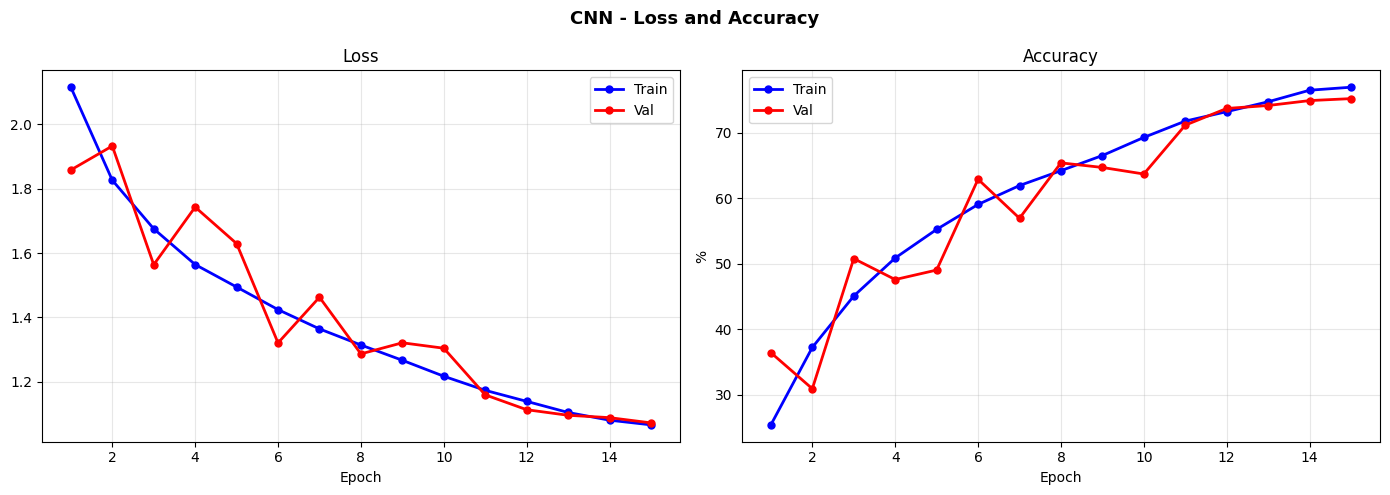


  CNN
  Accuracy     : 75.20%
  Macro Recall : 75.20%
  Macro F1     : 75.02%

              precision    recall  f1-score   support

    airplane       0.79      0.73      0.76       200
  automobile       0.87      0.89      0.88       200
        bird       0.65      0.69      0.67       200
         cat       0.53      0.45      0.49       200
        deer       0.73      0.73      0.73       200
         dog       0.64      0.71      0.67       200
        frog       0.77      0.81      0.79       200
       horse       0.84      0.75      0.79       200
        ship       0.83      0.90      0.86       200
       truck       0.85      0.87      0.86       200

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



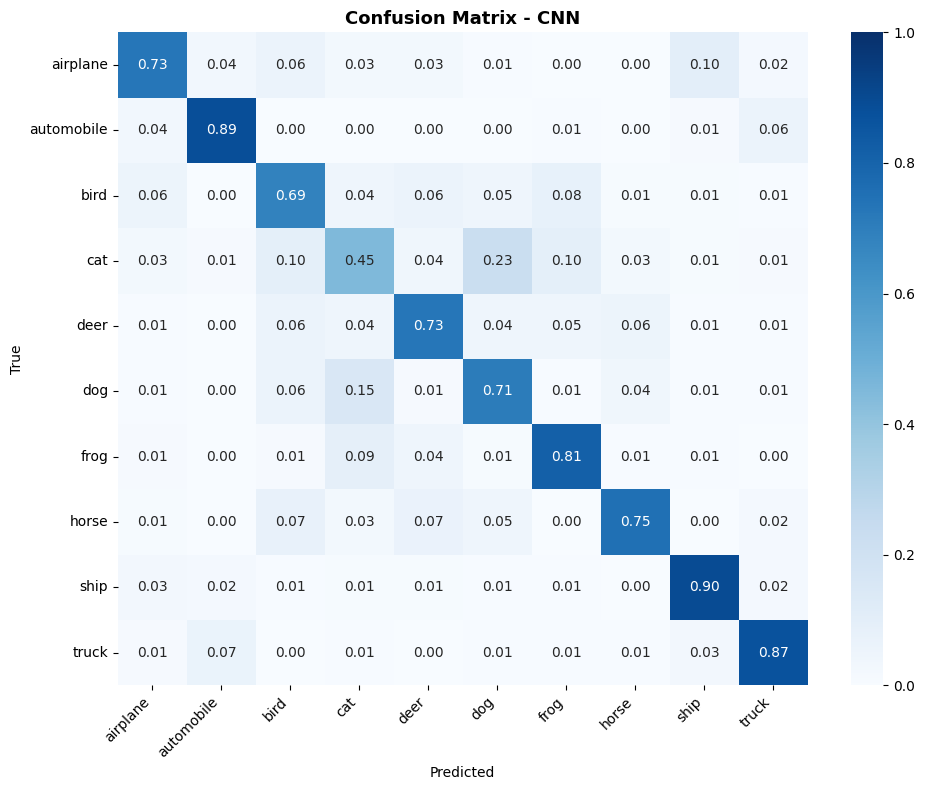

In [15]:
plot_history(cnn_history, "CNN - Loss and Accuracy")
_, _, cnn_preds, cnn_labels = evaluate(cnn_model, val_loader_basic, cnn_crit)
cnn_metrics = print_metrics(cnn_preds, cnn_labels, "CNN")
plot_confusion(cnn_preds, cnn_labels, "CNN")

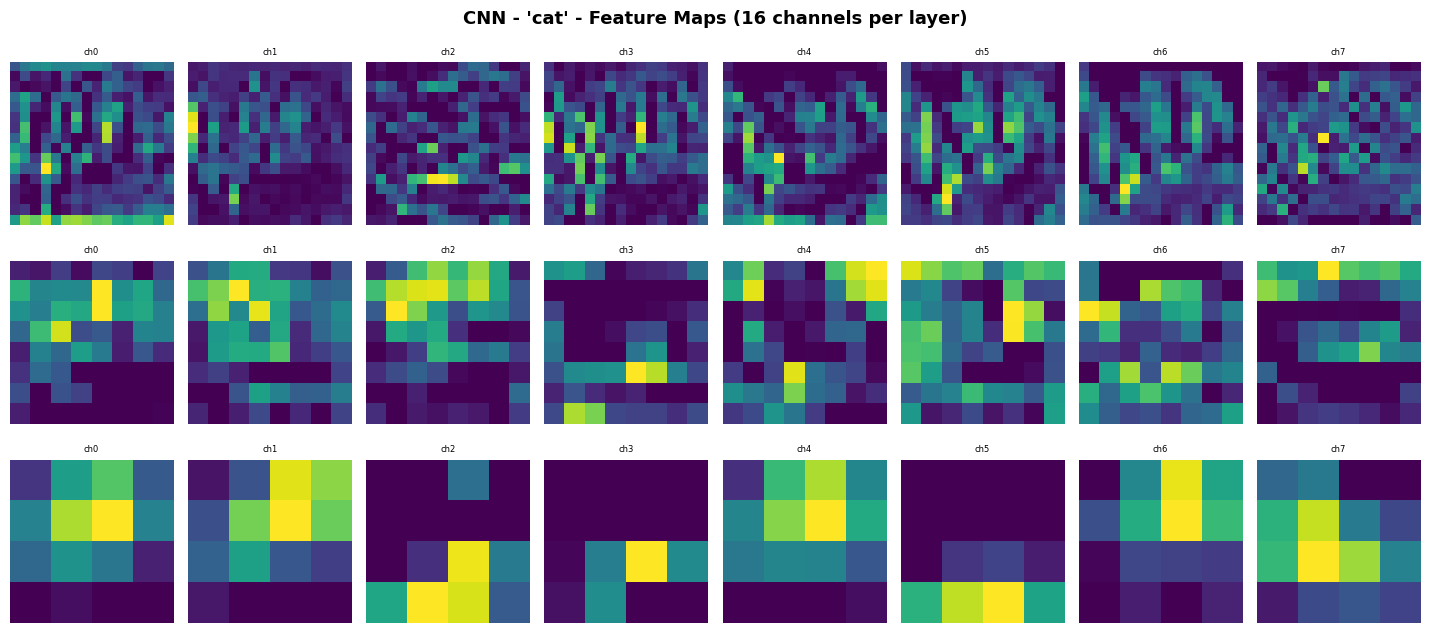

Block 1 (16x16): close to the original image. Each channel responds to a specific
  edge direction or color pattern across the spatial layout of the image.
Block 2 (8x8): more abstract. You can still roughly locate the object
  but individual feature maps now respond to compound patterns.
Block 3 (4x4): highly abstract. Each 4x4 grid cell represents a large
  region of the original image. Only high-level semantics remain.


In [16]:
# CNN feature maps after training
# We hook each of the three conv blocks to capture their output activations
cnn_layer_names = [
    ("Block 1 - 64ch 16x16", cnn_model.block1),
    ("Block 2 - 128ch 8x8",  cnn_model.block2),
    ("Block 3 - 256ch 4x4",  cnn_model.block3),
]
show_feature_maps(cnn_model, SAMPLE_TENSOR_BASIC, cnn_layer_names,
                  title_prefix=f"CNN - '{CLASSES[SAMPLE_LABEL]}'")

print("Block 1 (16x16): close to the original image. Each channel responds to a specific")
print("  edge direction or color pattern across the spatial layout of the image.")
print("Block 2 (8x8): more abstract. You can still roughly locate the object")
print("  but individual feature maps now respond to compound patterns.")
print("Block 3 (4x4): highly abstract. Each 4x4 grid cell represents a large")
print("  region of the original image. Only high-level semantics remain.")

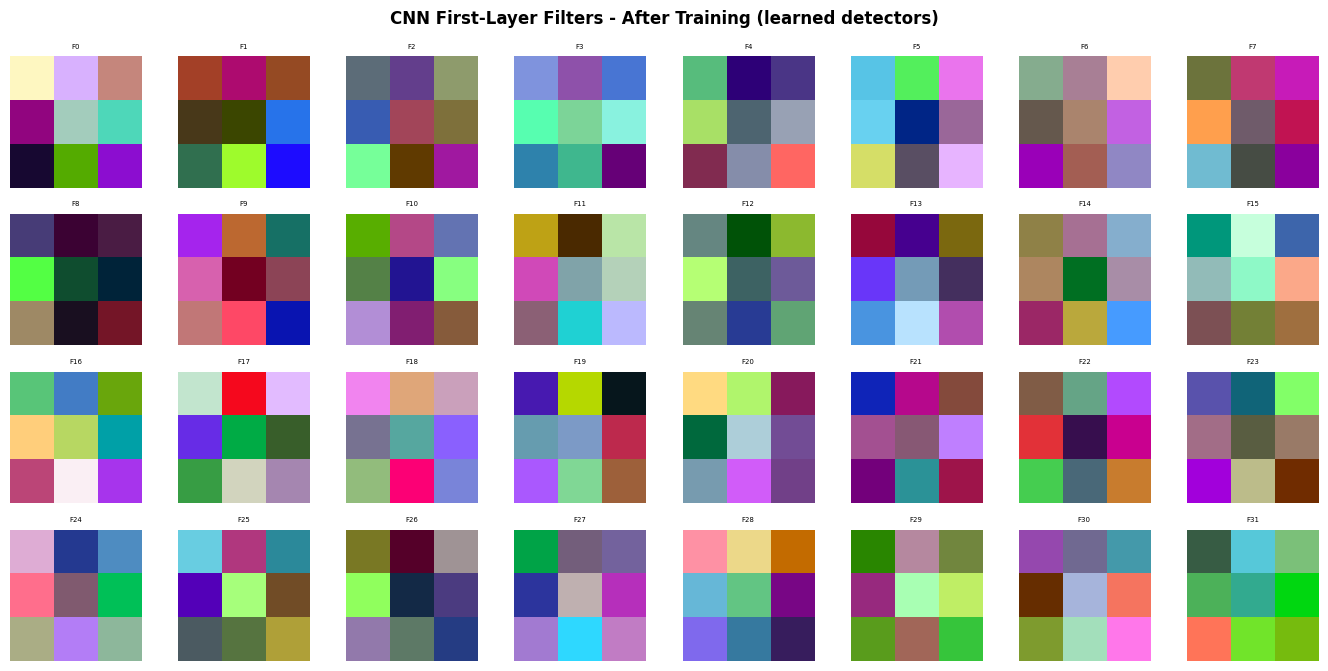

Before training: random noise, no structure.
After training: structured detectors have emerged.
Look for edge detectors (bright one side, dark the other),
color detectors (one channel dominates), and blob detectors.


In [17]:
# Filters after training - compare with the before plot above
filters_cnn_after = get_first_conv_filters(cnn_model)
plot_filters(filters_cnn_after, "CNN First-Layer Filters - After Training (learned detectors)", n=32, ncols=8)

print("Before training: random noise, no structure.")
print("After training: structured detectors have emerged.")
print("Look for edge detectors (bright one side, dark the other),")
print("color detectors (one channel dominates), and blob detectors.")

### CNN Results

Accuracy should be in the 70-78% range, a large jump from MLP.
The train/val gap is tighter because weight sharing limits overfitting.
The feature maps show a clear spatial hierarchy: coarse features at block 1
become increasingly abstract by block 3.
Edge and color detectors are visible in the trained filters,
replacing the random noise that existed before training.

---
## Part 3 - Transfer Learning with ResNet18

ResNet18 was pretrained on 1.2 million ImageNet images.
Its layers learned a general visual hierarchy that transfers directly to natural image tasks.

We replace only the final FC layer (which outputted 1000 class scores)
with a small head that outputs 10 scores for our classes.

Three scenarios with increasing degrees of freedom:

Scenario 3A - Entire backbone frozen, only the new head trains.
Scenario 3B - Early layers frozen (conv1, layer1, layer2), late layers (layer3, layer4) + head train.
Scenario 3C - Everything trains using a tiered learning rate pyramid.

In [18]:
def build_resnet18(freeze_mode="none"):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features   # 512
    model.fc = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_features, 256),
        nn.ReLU(inplace=True), nn.Dropout(0.2),
        nn.Linear(256, NUM_CLASSES)
    )
    if freeze_mode == "all":
        for name, p in model.named_parameters():
            if not name.startswith("fc"):
                p.requires_grad = False
    elif freeze_mode == "early":
        for name, p in model.named_parameters():
            if any(name.startswith(x) for x in ["conv1","bn1","layer1","layer2"]):
                p.requires_grad = False

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  freeze_mode : {freeze_mode}")
    print(f"  Trainable   : {trainable:,}  ({trainable/total*100:.1f}%)")
    print(f"  Frozen      : {total-trainable:,}  ({(total-trainable)/total*100:.1f}%)")
    return model

print("Builder defined.")

Builder defined.


### Scenario 3A - FC Head Only

In [19]:
print("Building ResNet18 - 3A\n")
model_3a = build_resnet18(freeze_mode="all").to(DEVICE)

optim_3a = optim.Adam([p for p in model_3a.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
crit_3a  = nn.CrossEntropyLoss()
sched_3a = optim.lr_scheduler.StepLR(optim_3a, step_size=4, gamma=0.5)

print("\nTraining 3A...\n")
history_3a = run_training(model_3a, train_loader_pt, val_loader_pt,
                           optim_3a, crit_3a, sched_3a,
                           epochs=EPOCHS_TL, model_name="TL-3A (FC only)")

Building ResNet18 - 3A

  freeze_mode : all
  Trainable   : 133,898  (1.2%)
  Frozen      : 11,176,512  (98.8%)

Training 3A...

  Epoch   1/10  |  Train Loss: 1.1959  Acc:  58.34%  |  Val Loss: 0.7936  Acc:  71.15% <- best
  Epoch   2/10  |  Train Loss: 0.9311  Acc:  67.70%  |  Val Loss: 0.7282  Acc:  74.80% <- best
  Epoch   3/10  |  Train Loss: 0.8883  Acc:  69.05%  |  Val Loss: 0.6909  Acc:  76.00% <- best
  Epoch   4/10  |  Train Loss: 0.8709  Acc:  70.14%  |  Val Loss: 0.6418  Acc:  77.60% <- best
  Epoch   5/10  |  Train Loss: 0.8192  Acc:  71.56%  |  Val Loss: 0.6399  Acc:  77.55%
  Epoch   6/10  |  Train Loss: 0.8202  Acc:  71.40%  |  Val Loss: 0.6341  Acc:  79.00% <- best
  Epoch   7/10  |  Train Loss: 0.7994  Acc:  72.18%  |  Val Loss: 0.6259  Acc:  79.65% <- best
  Epoch   8/10  |  Train Loss: 0.7868  Acc:  72.89%  |  Val Loss: 0.6065  Acc:  79.15%
  Epoch   9/10  |  Train Loss: 0.7710  Acc:  73.02%  |  Val Loss: 0.5971  Acc:  79.80% <- best
  Epoch  10/10  |  Train Loss: 0

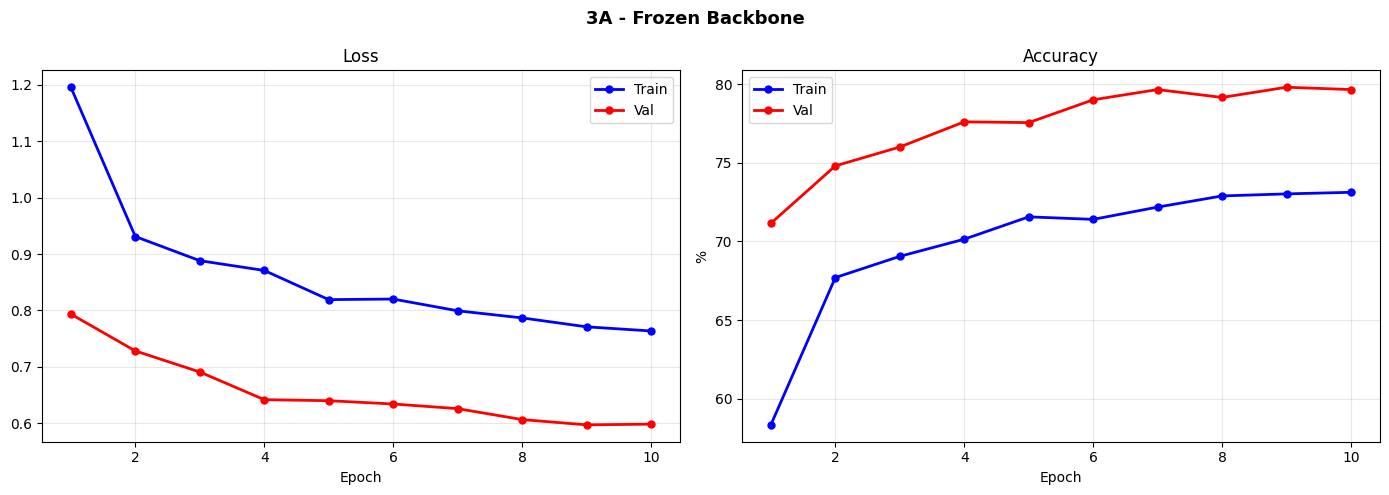


  TL-3A (FC only)
  Accuracy     : 79.80%
  Macro Recall : 79.80%
  Macro F1     : 79.61%

              precision    recall  f1-score   support

    airplane       0.85      0.80      0.82       200
  automobile       0.88      0.89      0.88       200
        bird       0.81      0.75      0.78       200
         cat       0.71      0.59      0.64       200
        deer       0.81      0.70      0.75       200
         dog       0.74      0.82      0.78       200
        frog       0.77      0.89      0.82       200
       horse       0.77      0.84      0.81       200
        ship       0.82      0.84      0.83       200
       truck       0.83      0.85      0.84       200

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



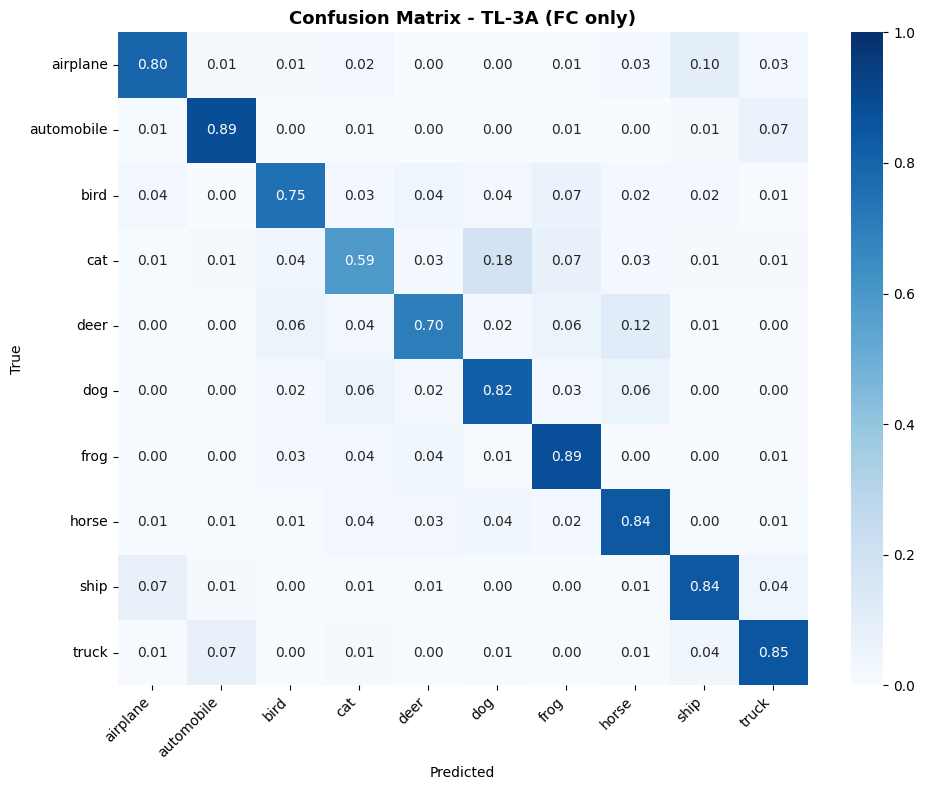

In [20]:
plot_history(history_3a, "3A - Frozen Backbone")
_, _, preds_3a, labels_3a = evaluate(model_3a, val_loader_pt, crit_3a)
metrics_3a = print_metrics(preds_3a, labels_3a, "TL-3A (FC only)")
plot_confusion(preds_3a, labels_3a, "TL-3A (FC only)")

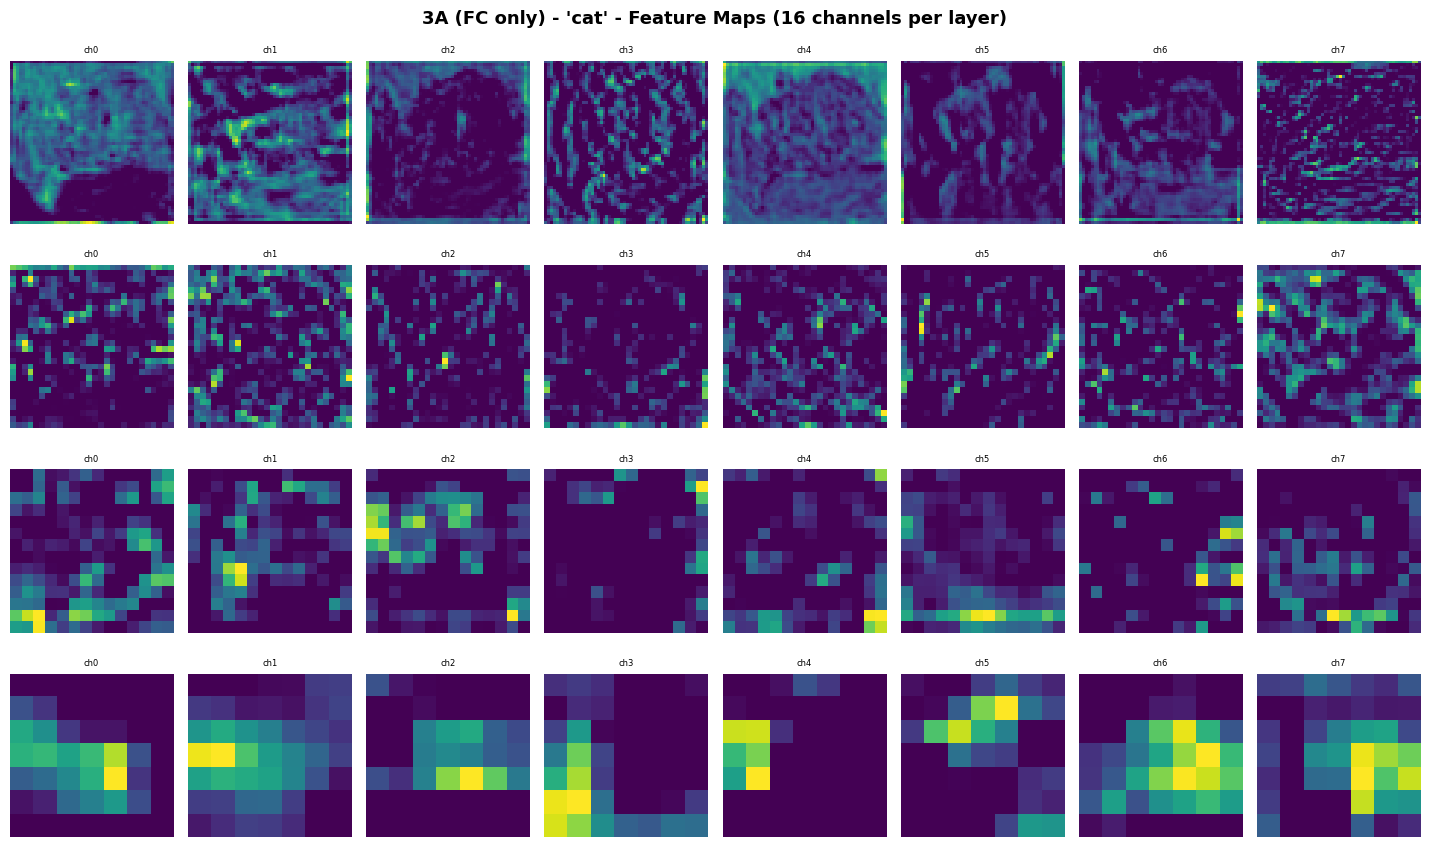

The backbone was frozen so these feature maps are identical to what
a vanilla pretrained ResNet would produce. The head learned to classify
based on these fixed features without modifying them.


In [21]:
# Feature maps for 3A - ResNet layers
# We hook the output of each residual layer group
layer_names_3a = [
    ("layer1 - 64ch 56x56",  model_3a.layer1),
    ("layer2 - 128ch 28x28", model_3a.layer2),
    ("layer3 - 256ch 14x14", model_3a.layer3),
    ("layer4 - 512ch 7x7",   model_3a.layer4),
]
show_feature_maps(model_3a, SAMPLE_TENSOR_PT, layer_names_3a,
                  title_prefix=f"3A (FC only) - '{CLASSES[SAMPLE_LABEL]}'")

print("The backbone was frozen so these feature maps are identical to what")
print("a vanilla pretrained ResNet would produce. The head learned to classify")
print("based on these fixed features without modifying them.")

### Scenario 3B - Fine-tune Late Layers

In [22]:
print("Building ResNet18 - 3B\n")
model_3b = build_resnet18(freeze_mode="early").to(DEVICE)

backbone_p = [p for n,p in model_3b.named_parameters() if p.requires_grad and not n.startswith("fc")]
head_p     = [p for n,p in model_3b.named_parameters() if p.requires_grad and n.startswith("fc")]

optim_3b = optim.Adam([{"params": backbone_p, "lr": 1e-4},
                        {"params": head_p,     "lr": 1e-3}], weight_decay=1e-4)
crit_3b  = nn.CrossEntropyLoss()
sched_3b = optim.lr_scheduler.CosineAnnealingLR(optim_3b, T_max=EPOCHS_TL)

print("\nTraining 3B...\n")
history_3b = run_training(model_3b, train_loader_pt, val_loader_pt,
                           optim_3b, crit_3b, sched_3b,
                           epochs=EPOCHS_TL, model_name="TL-3B (late layers)")

Building ResNet18 - 3B

  freeze_mode : early
  Trainable   : 10,627,338  (94.0%)
  Frozen      : 683,072  (6.0%)

Training 3B...

  Epoch   1/10  |  Train Loss: 0.6778  Acc:  76.77%  |  Val Loss: 0.3791  Acc:  86.90% <- best
  Epoch   2/10  |  Train Loss: 0.2991  Acc:  89.96%  |  Val Loss: 0.3485  Acc:  88.60% <- best
  Epoch   3/10  |  Train Loss: 0.1815  Acc:  93.85%  |  Val Loss: 0.3119  Acc:  90.30% <- best
  Epoch   4/10  |  Train Loss: 0.1222  Acc:  96.01%  |  Val Loss: 0.3652  Acc:  89.45%
  Epoch   5/10  |  Train Loss: 0.0787  Acc:  97.25%  |  Val Loss: 0.3633  Acc:  90.00%
  Epoch   6/10  |  Train Loss: 0.0543  Acc:  98.27%  |  Val Loss: 0.3941  Acc:  89.85%
  Epoch   7/10  |  Train Loss: 0.0379  Acc:  98.89%  |  Val Loss: 0.3440  Acc:  91.05% <- best
  Epoch   8/10  |  Train Loss: 0.0206  Acc:  99.36%  |  Val Loss: 0.3572  Acc:  91.15% <- best
  Epoch   9/10  |  Train Loss: 0.0146  Acc:  99.51%  |  Val Loss: 0.3402  Acc:  91.50% <- best
  Epoch  10/10  |  Train Loss: 0.0115 

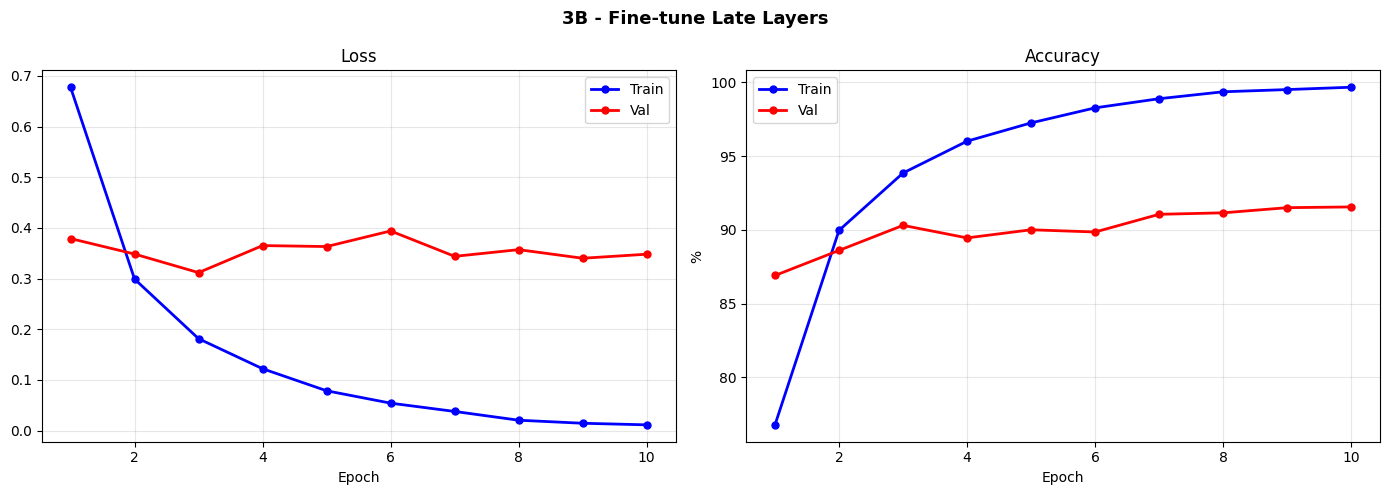


  TL-3B (late layers)
  Accuracy     : 91.55%
  Macro Recall : 91.55%
  Macro F1     : 91.53%

              precision    recall  f1-score   support

    airplane       0.94      0.94      0.94       200
  automobile       0.95      0.97      0.96       200
        bird       0.92      0.92      0.92       200
         cat       0.87      0.78      0.82       200
        deer       0.91      0.92      0.91       200
         dog       0.81      0.88      0.84       200
        frog       0.95      0.95      0.95       200
       horse       0.91      0.94      0.92       200
        ship       0.96      0.94      0.95       200
       truck       0.95      0.93      0.94       200

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



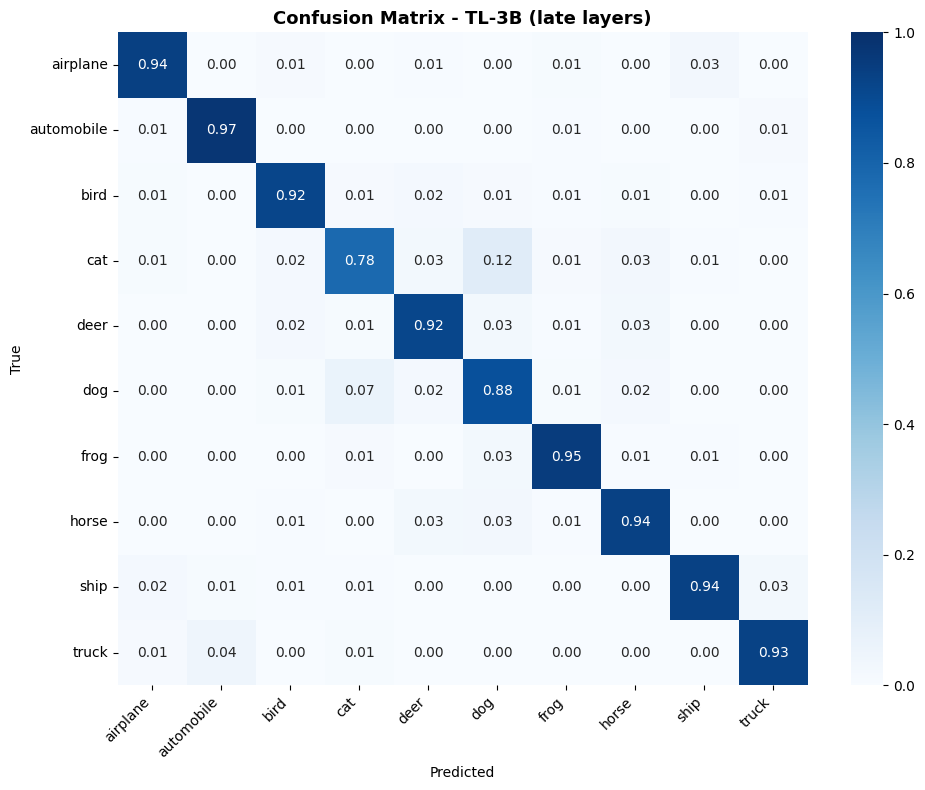

In [23]:
plot_history(history_3b, "3B - Fine-tune Late Layers")
_, _, preds_3b, labels_3b = evaluate(model_3b, val_loader_pt, crit_3b)
metrics_3b = print_metrics(preds_3b, labels_3b, "TL-3B (late layers)")
plot_confusion(preds_3b, labels_3b, "TL-3B (late layers)")

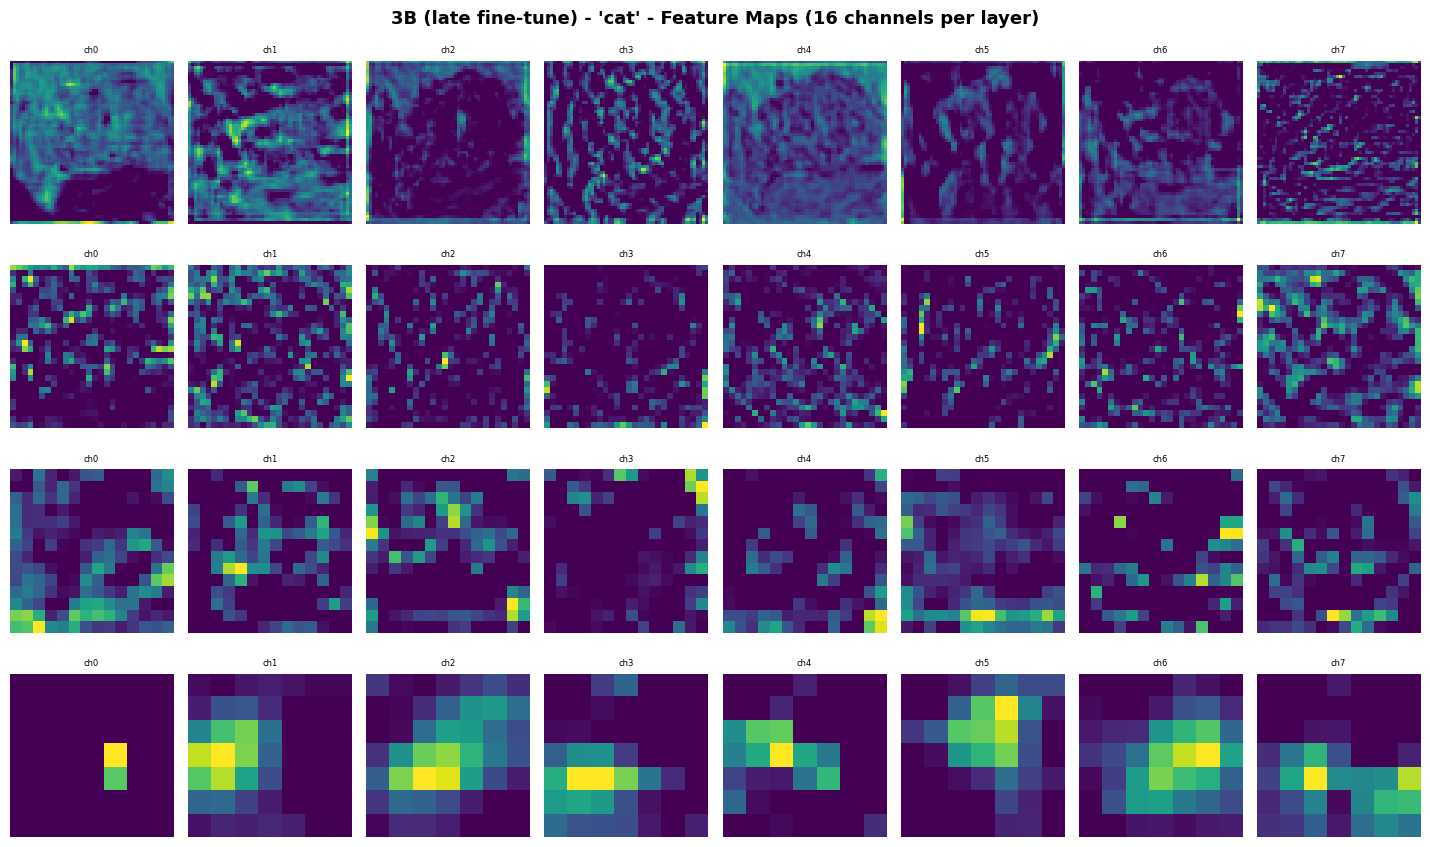

layer1 and layer2 are identical to 3A because they were frozen.
layer3 and layer4 have adapted to CIFAR-10 features.
Compare these to the 3A maps to see how fine-tuning changes the representation.


In [24]:
layer_names_3b = [
    ("layer1 - 64ch 56x56",  model_3b.layer1),
    ("layer2 - 128ch 28x28", model_3b.layer2),
    ("layer3 - 256ch 14x14", model_3b.layer3),
    ("layer4 - 512ch 7x7",   model_3b.layer4),
]
show_feature_maps(model_3b, SAMPLE_TENSOR_PT, layer_names_3b,
                  title_prefix=f"3B (late fine-tune) - '{CLASSES[SAMPLE_LABEL]}'")

print("layer1 and layer2 are identical to 3A because they were frozen.")
print("layer3 and layer4 have adapted to CIFAR-10 features.")
print("Compare these to the 3A maps to see how fine-tuning changes the representation.")

### Scenario 3C - Full Fine-tune

In [25]:
print("Building ResNet18 - 3C\n")
model_3c = build_resnet18(freeze_mode="none").to(DEVICE)

def tiered_groups(model):
    def pick(prefixes):
        return [p for n,p in model.named_parameters()
                if any(n.startswith(x) for x in prefixes)]
    return [
        {"params": pick(["conv1","bn1","layer1"]), "lr": 5e-6},
        {"params": pick(["layer2","layer3"]),      "lr": 5e-5},
        {"params": pick(["layer4"]),               "lr": 1e-4},
        {"params": [p for n,p in model.named_parameters() if n.startswith("fc")], "lr": 5e-4},
    ]

optim_3c = optim.Adam(tiered_groups(model_3c), weight_decay=1e-4)
crit_3c  = nn.CrossEntropyLoss(label_smoothing=0.1)
sched_3c = optim.lr_scheduler.CosineAnnealingLR(optim_3c, T_max=EPOCHS_TL)

print("\nTraining 3C...\n")
history_3c = run_training(model_3c, train_loader_pt, val_loader_pt,
                           optim_3c, crit_3c, sched_3c,
                           epochs=EPOCHS_TL, model_name="TL-3C (full)")

Building ResNet18 - 3C

  freeze_mode : none
  Trainable   : 11,310,410  (100.0%)
  Frozen      : 0  (0.0%)

Training 3C...

  Epoch   1/10  |  Train Loss: 1.0523  Acc:  77.72%  |  Val Loss: 0.8120  Acc:  88.20% <- best
  Epoch   2/10  |  Train Loss: 0.7428  Acc:  92.13%  |  Val Loss: 0.7403  Acc:  91.40% <- best
  Epoch   3/10  |  Train Loss: 0.6501  Acc:  96.26%  |  Val Loss: 0.7448  Acc:  90.70%
  Epoch   4/10  |  Train Loss: 0.6091  Acc:  98.02%  |  Val Loss: 0.7069  Acc:  91.85% <- best
  Epoch   5/10  |  Train Loss: 0.5739  Acc:  99.09%  |  Val Loss: 0.6969  Acc:  92.55% <- best
  Epoch   6/10  |  Train Loss: 0.5592  Acc:  99.40%  |  Val Loss: 0.6902  Acc:  92.80% <- best
  Epoch   7/10  |  Train Loss: 0.5491  Acc:  99.71%  |  Val Loss: 0.6889  Acc:  92.65%
  Epoch   8/10  |  Train Loss: 0.5419  Acc:  99.81%  |  Val Loss: 0.6833  Acc:  92.85% <- best
  Epoch   9/10  |  Train Loss: 0.5375  Acc:  99.92%  |  Val Loss: 0.6833  Acc:  92.45%
  Epoch  10/10  |  Train Loss: 0.5352  Acc: 

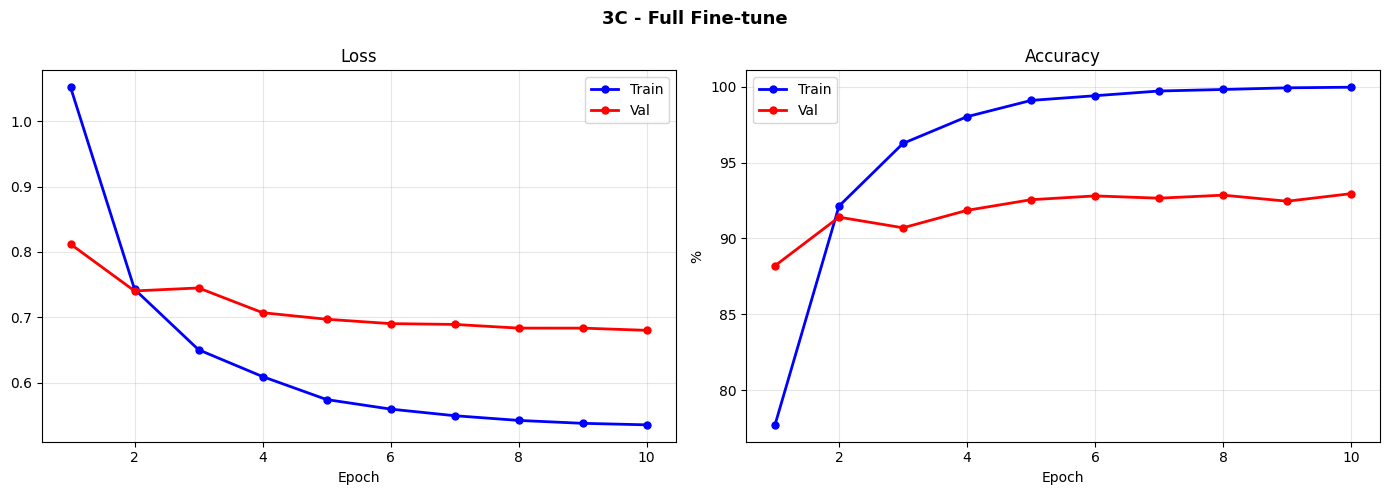


  TL-3C (full)
  Accuracy     : 92.95%
  Macro Recall : 92.95%
  Macro F1     : 92.94%

              precision    recall  f1-score   support

    airplane       0.95      0.95      0.95       200
  automobile       0.95      0.98      0.97       200
        bird       0.96      0.91      0.93       200
         cat       0.88      0.81      0.84       200
        deer       0.93      0.92      0.92       200
         dog       0.83      0.91      0.87       200
        frog       0.93      0.96      0.95       200
       horse       0.93      0.94      0.94       200
        ship       0.97      0.96      0.97       200
       truck       0.96      0.95      0.95       200

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



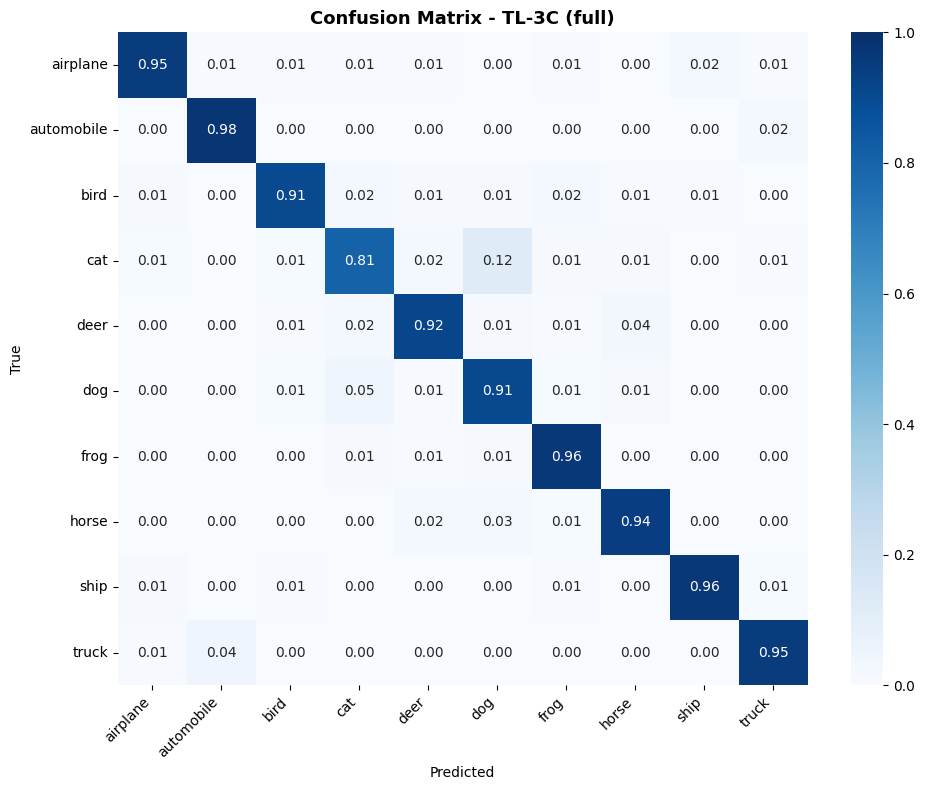

In [26]:
plot_history(history_3c, "3C - Full Fine-tune")
_, _, preds_3c, labels_3c = evaluate(model_3c, val_loader_pt, crit_3c)
metrics_3c = print_metrics(preds_3c, labels_3c, "TL-3C (full)")
plot_confusion(preds_3c, labels_3c, "TL-3C (full)")

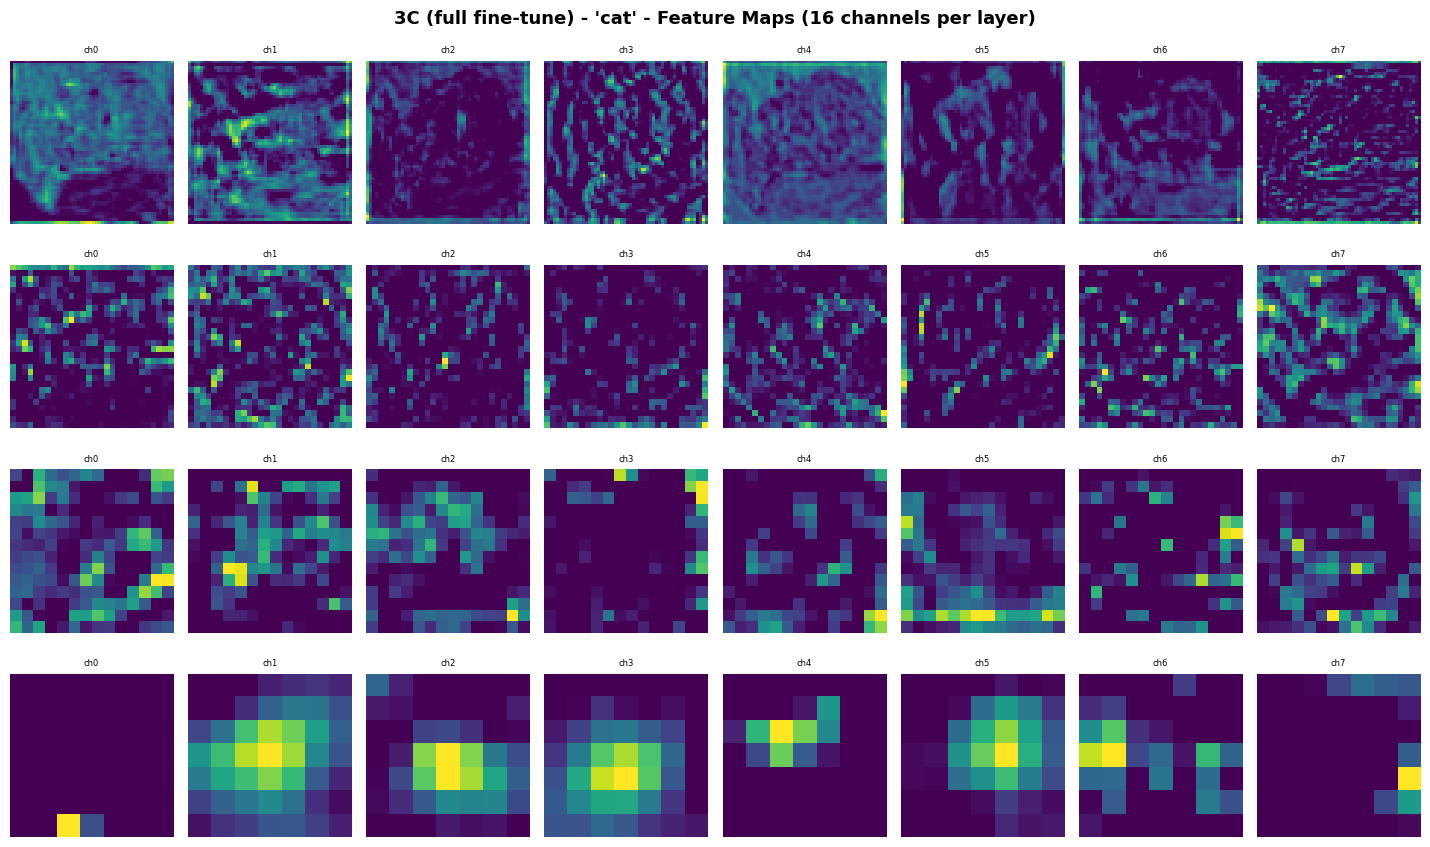

With all layers free to update, every layer has adapted to CIFAR-10.
The tiered learning rate kept early-layer changes minimal to avoid
destroying universal low-level features.


In [27]:
layer_names_3c = [
    ("layer1 - 64ch 56x56",  model_3c.layer1),
    ("layer2 - 128ch 28x28", model_3c.layer2),
    ("layer3 - 256ch 14x14", model_3c.layer3),
    ("layer4 - 512ch 7x7",   model_3c.layer4),
]
show_feature_maps(model_3c, SAMPLE_TENSOR_PT, layer_names_3c,
                  title_prefix=f"3C (full fine-tune) - '{CLASSES[SAMPLE_LABEL]}'")

print("With all layers free to update, every layer has adapted to CIFAR-10.")
print("The tiered learning rate kept early-layer changes minimal to avoid")
print("destroying universal low-level features.")

---
## Part 4 - Filter Visualization: Before and After

We visualize the first convolutional layer filters for both the CNN
and ResNet18 to see what changed during training.

First-layer filters are visualized as RGB images because they operate
directly on raw pixel values. A filter that looks like a high/low brightness split
is an edge detector. A filter dominated by one color is a color-channel detector.

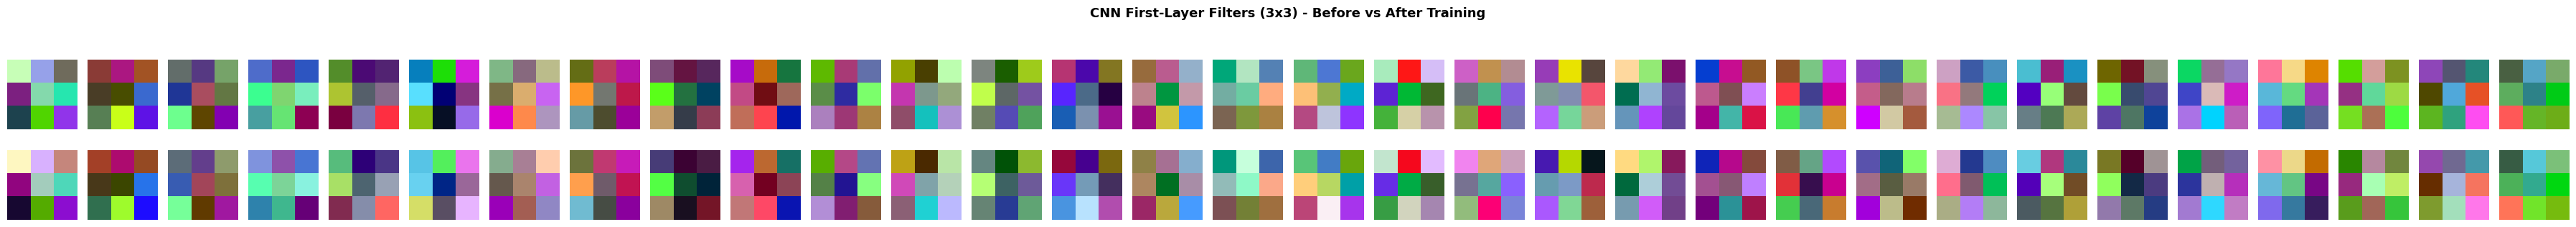

In [28]:
# CNN: side by side
fig, axes_all = plt.subplots(2, 32, figsize=(36, 3.5))
for row, (filters, lbl) in enumerate([(filters_cnn_before, "Before (random init)"),
                                        (filters_cnn_after,  "After training")]):
    for i in range(32):
        f = filters[i]
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        axes_all[row][i].imshow(f.permute(1,2,0).numpy(), interpolation="nearest")
        axes_all[row][i].axis("off")
    axes_all[row][0].set_ylabel(lbl, rotation=0, labelpad=110,
                                fontsize=9, fontweight="bold", va="center")

plt.suptitle("CNN First-Layer Filters (3x3) - Before vs After Training",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

ResNet conv1 shape: torch.Size([64, 3, 7, 7])  (64 filters of 7x7)


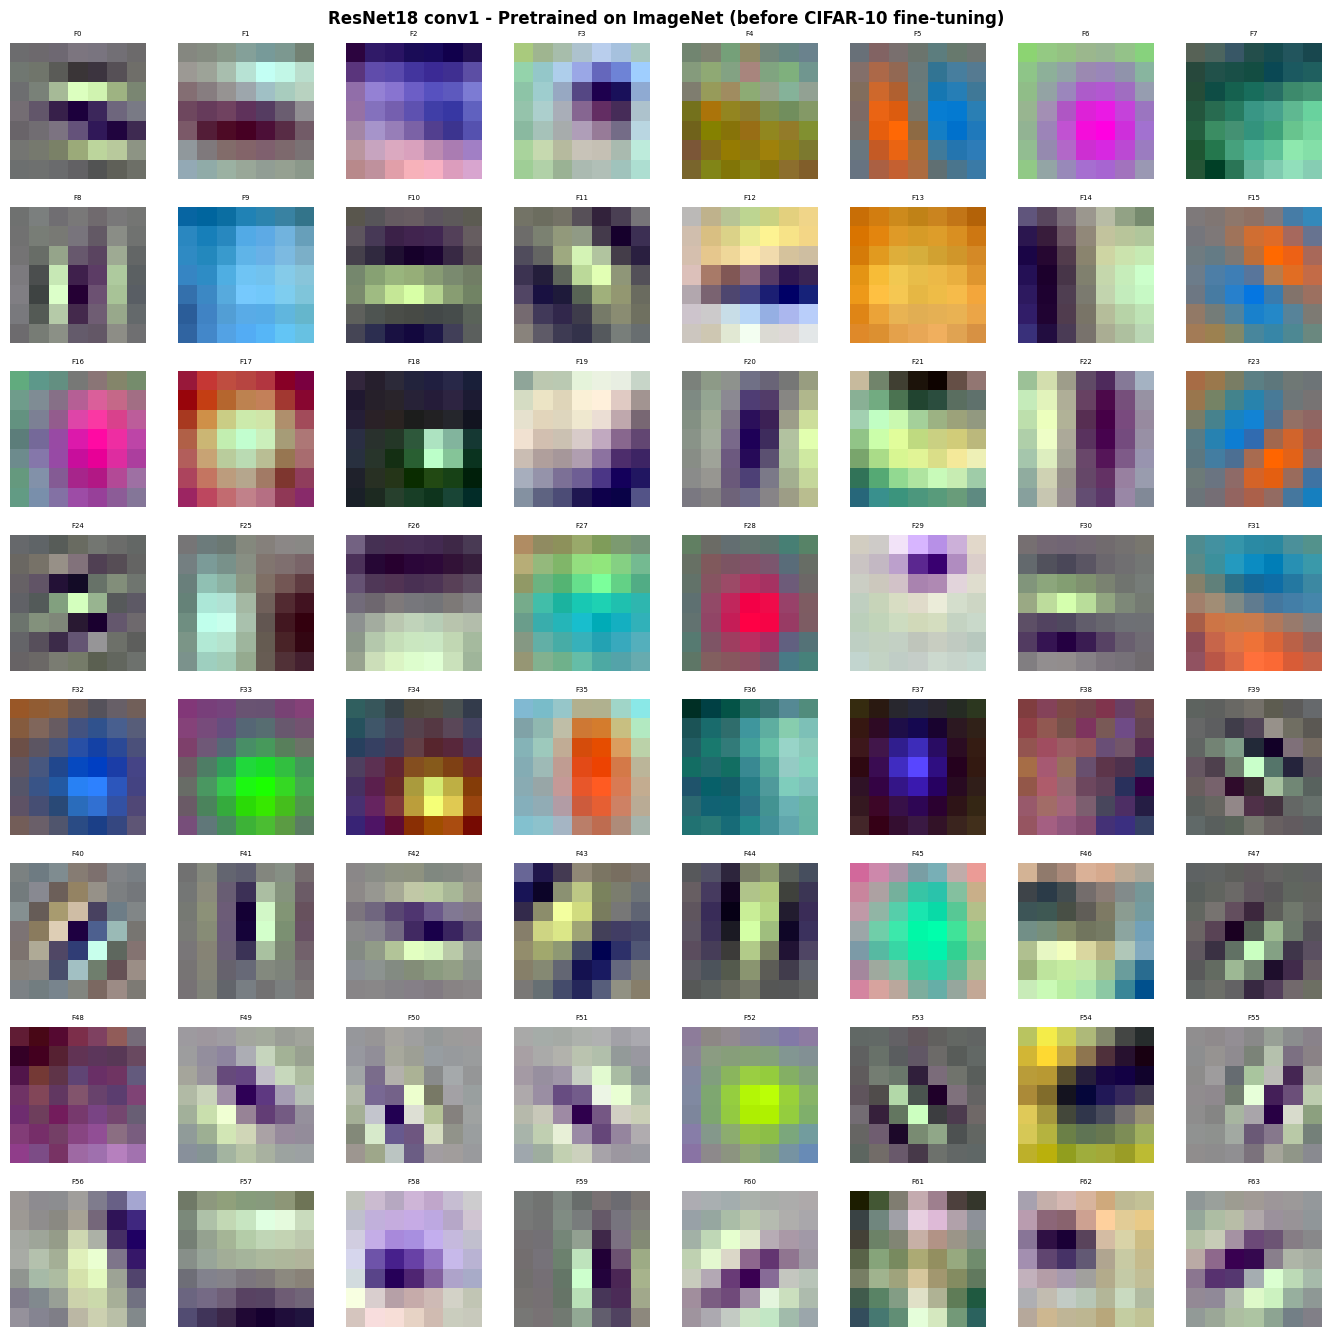

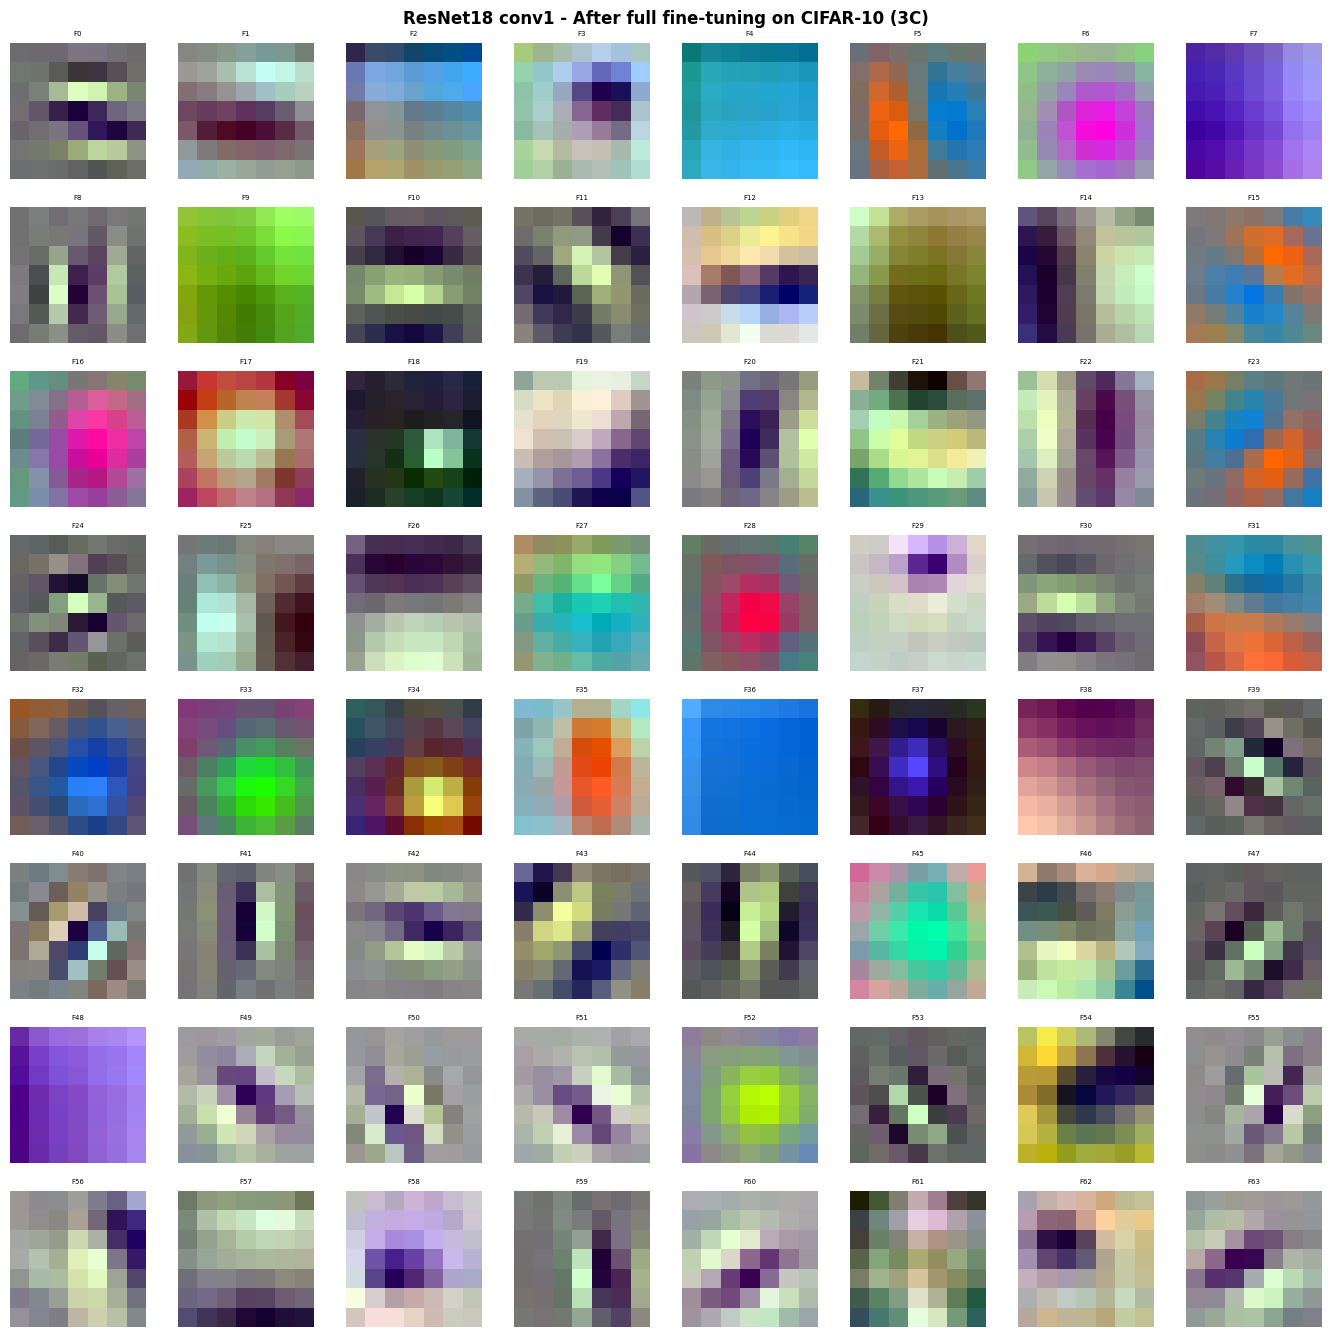

Average filter change : 0.000151  (0.20% relative)

The filters changed by a tiny amount despite 10 epochs of training.
The 5e-6 learning rate on early layers protected the universal edge
and color detectors from being overwritten by CIFAR-10 patterns.


In [29]:
# ResNet18: ImageNet pretrained vs after 3C fine-tuning
resnet_ref = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
filters_resnet_pre  = resnet_ref.conv1.weight.detach().cpu().clone()
filters_resnet_post = model_3c.conv1.weight.detach().cpu().clone()

print(f"ResNet conv1 shape: {filters_resnet_pre.shape}  (64 filters of 7x7)")

plot_filters(filters_resnet_pre,
             "ResNet18 conv1 - Pretrained on ImageNet (before CIFAR-10 fine-tuning)",
             n=64, ncols=8)
plot_filters(filters_resnet_post,
             "ResNet18 conv1 - After full fine-tuning on CIFAR-10 (3C)",
             n=64, ncols=8)

delta    = (filters_resnet_post - filters_resnet_pre).abs().mean().item()
relative = delta / filters_resnet_pre.abs().mean().item() * 100
print(f"Average filter change : {delta:.6f}  ({relative:.2f}% relative)")
print()
print("The filters changed by a tiny amount despite 10 epochs of training.")
print("The 5e-6 learning rate on early layers protected the universal edge")
print("and color detectors from being overwritten by CIFAR-10 patterns.")

---
## Final Comparison

In [30]:
all_results = {
    "MLP":             {**mlp_metrics,  "best_val_acc": mlp_history["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in MLP().parameters())},
    "CNN":             {**cnn_metrics,  "best_val_acc": cnn_history["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in CNN().parameters())},
    "TL-3A (FC)":      {**metrics_3a,   "best_val_acc": history_3a["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in model_3a.parameters() if p.requires_grad)},
    "TL-3B (Late)":    {**metrics_3b,   "best_val_acc": history_3b["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in model_3b.parameters() if p.requires_grad)},
    "TL-3C (Full)":    {**metrics_3c,   "best_val_acc": history_3c["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in model_3c.parameters() if p.requires_grad)},
}

print(f"{'Model':<20}  {'Val Acc':>8}  {'Recall':>8}  {'F1':>8}  {'Trainable Params':>18}")
print("-" * 72)
for name, m in all_results.items():
    print(f"{name:<20}  {m['accuracy']*100:>7.2f}%  {m['macro_recall']*100:>7.2f}%"
          f"  {m['macro_f1']*100:>7.2f}%  {m['trainable_params']:>18,}")

with open("results_summary.json", "w") as f:
    json.dump({k: {kk: float(vv) for kk,vv in v.items()} for k,v in all_results.items()}, f, indent=2)
print("\nSaved to results_summary.json")

Model                  Val Acc    Recall        F1    Trainable Params
------------------------------------------------------------------------
MLP                     48.20%    48.20%    47.33%           3,809,034
CNN                     75.20%    75.20%    75.02%           1,180,490
TL-3A (FC)              79.80%    79.80%    79.61%             133,898
TL-3B (Late)            91.55%    91.55%    91.53%          10,627,338
TL-3C (Full)            92.95%    92.95%    92.94%          11,310,410

Saved to results_summary.json


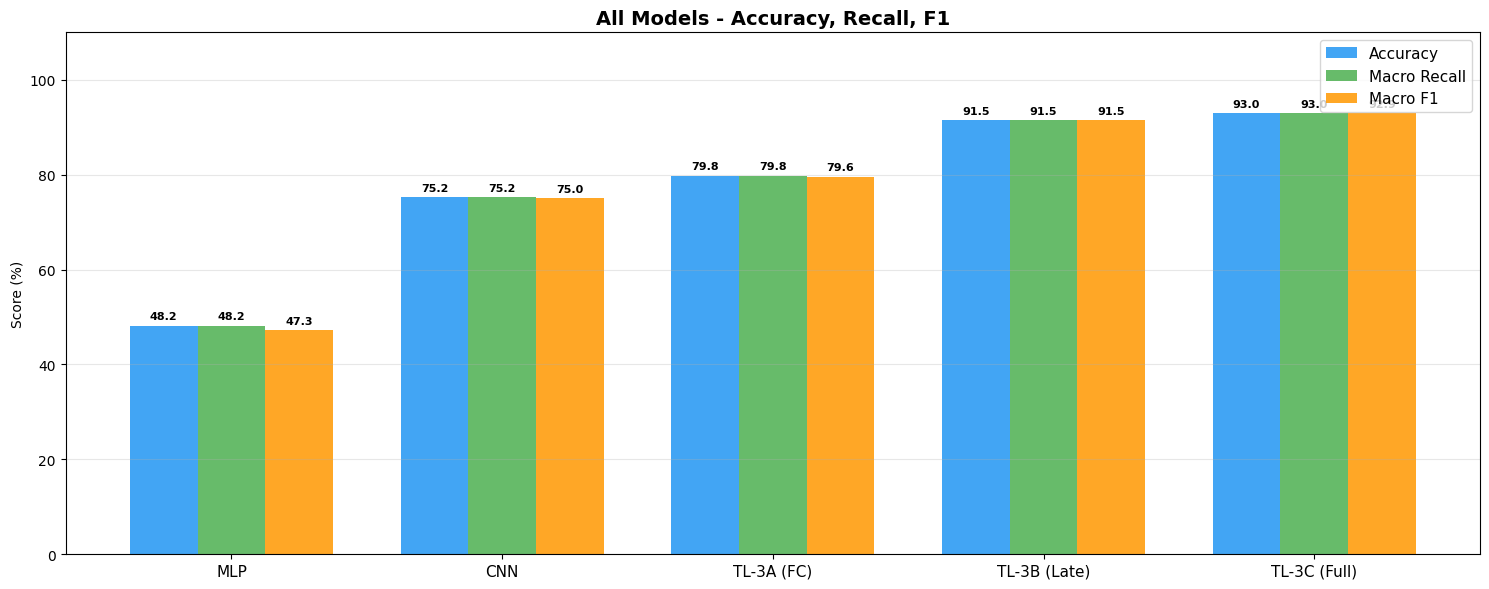

In [31]:
names   = list(all_results.keys())
accs    = [v["accuracy"]*100     for v in all_results.values()]
recalls = [v["macro_recall"]*100 for v in all_results.values()]
f1s     = [v["macro_f1"]*100     for v in all_results.values()]
x, w    = np.arange(len(names)), 0.25

fig, ax = plt.subplots(figsize=(15, 6))
for offset, vals, lbl, color in [(-w, accs, "Accuracy", "#2196F3"),
                                   ( 0, recalls, "Macro Recall", "#4CAF50"),
                                   ( w, f1s, "Macro F1", "#FF9800")]:
    bars = ax.bar(x + offset, vals, w, label=lbl, color=color, alpha=0.85)
    for bar in bars:
        ax.annotate(f"{bar.get_height():.1f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0,3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Score (%)"); ax.set_ylim(0, 110)
ax.set_title("All Models - Accuracy, Recall, F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

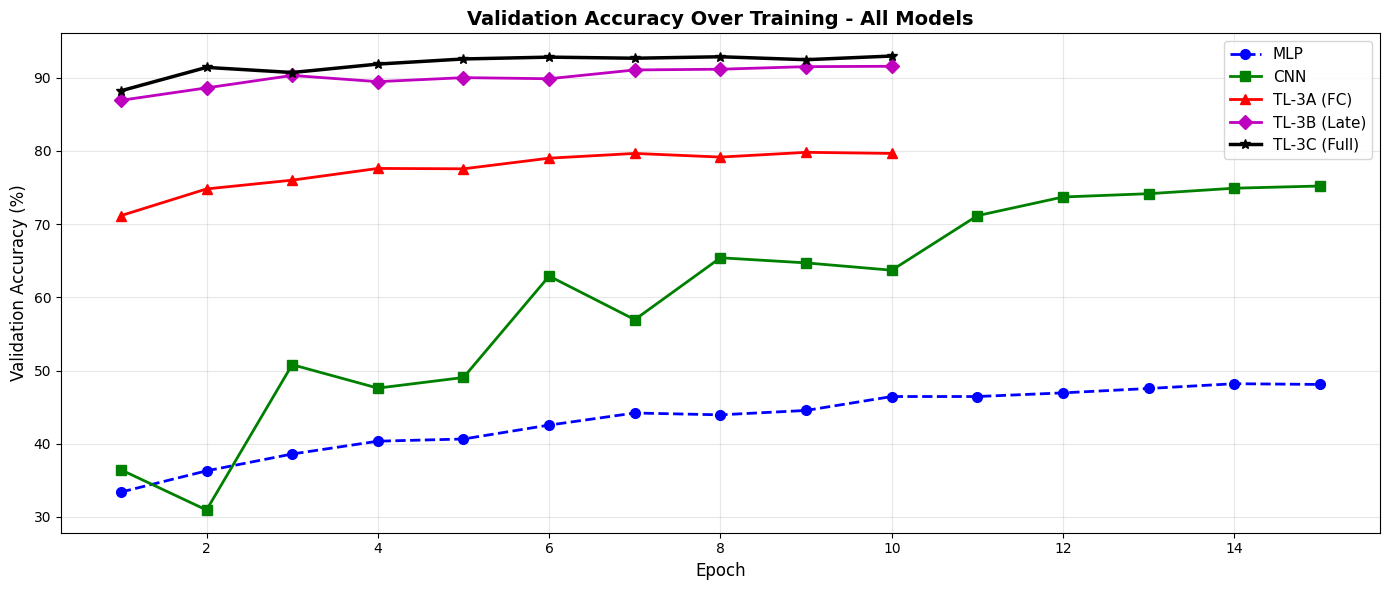

Transfer learning models start much higher from epoch 1 because
the backbone already extracts meaningful features before any fine-tuning.


In [32]:
fig, ax = plt.subplots(figsize=(14, 6))
curves = [
    (mlp_history,  "MLP",             "b--", "o",  2.0),
    (cnn_history,  "CNN",             "g-",  "s",  2.0),
    (history_3a,   "TL-3A (FC)",      "r-",  "^",  2.0),
    (history_3b,   "TL-3B (Late)",    "m-",  "D",  2.0),
    (history_3c,   "TL-3C (Full)",    "k-",  "*",  2.5),
]
for h, name, style, marker, lw in curves:
    ep = range(1, len(h["val_acc"]) + 1)
    ax.plot(ep, [a*100 for a in h["val_acc"]], style, marker=marker, ms=7, label=name, lw=lw)

ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Validation Accuracy Over Training - All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Transfer learning models start much higher from epoch 1 because")
print("the backbone already extracts meaningful features before any fine-tuning.")